# 난지 변화량 예측 노트북

- 원본: `nanji_ML.ipynb`
- 변경점: 타깃을 `estimated_active_cars_change`로 전환
- 주의: 변화량은 음수가 가능하므로 비음수 clipping을 제거함
- 운영 해석: `다음 시점 차량수 = 현재 실제 차량수 + 예측 변화량`


# 난지 한강공원 시간별 주차 예측 전체 프로세스

이 노트북은 난지 한강공원 주차장의 시간대별 주차 변화량을 예측하기 위해, 데이터를 확인하고 전처리한 뒤 모델을 만들고 성능을 평가하는 전 과정을 정리한 기록입니다.

이 노트북에서 하는 일:

- 어떤 데이터를 쓰는지 확인
- 운영시간 기준에 맞는 데이터인지 점검
- 데이터 품질, 분포, 이상값 여부를 점검
- 시간대 패턴과 월별 보정값을 만들기
- Ridge 모델 학습과 성능 비교
- 결과를 변화량 운영 방식으로 해석하기

예측 대상은 `estimated_active_cars_change`이며, 이는 **이전 시간 대비 추정 활성 차량 수의 변화량**입니다. 양수는 증가, 음수는 감소를 뜻합니다.


In [1]:
%matplotlib inline
import koreanize_matplotlib
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
from __future__ import annotations

import math
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from scipy import stats
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().resolve()
if ROOT.name == 'Note' and ROOT.parent.name == 'hmw':
    ROOT = ROOT.parents[1]

DATASET_PATH = ROOT / 'ksm/nanji_hourly_modeling/nanji_hourly_model_dataset_2020_2026.csv'
RAW_DAILY_PATH = ROOT / 'hmw/Data/한강공원 주차장 일별 이용 현황.csv'
METHODOLOGY_PATH = ROOT / 'ksm/nanji_hourly_modeling/nanji_hourly_dataset_methodology.md'
FEATURE_DICT_PATH = ROOT / 'ksm/nanji_hourly_modeling/nanji_hourly_feature_dictionary.md'
WEATHER_DATA_DIR = ROOT / 'ose/Data'
OUTPUT_DIR = ROOT / 'hmw/Note/nanji_outputs_change'
REPORT_PATH = ROOT / 'hmw/Note/nanji_weighted_ridge_change_modeling_report.md'
OPERATING_HOURS = list(range(6, 24))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'estimated_active_cars_change'
ALPHA_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
DAY_TYPE_ORDER = ['weekday', 'offday']
WEATHER_FEATURE_COLUMNS = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
    'precipitation', 'rain', 'snowfall', 'snow_depth', 'weather_code', 'pressure_msl',
    'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation',
    'direct_radiation', 'diffuse_radiation', 'sunshine_duration',
]

print('ROOT:', ROOT)
print('DATASET_PATH:', DATASET_PATH)
print('RAW_DAILY_PATH:', RAW_DAILY_PATH)
print('REPORT_PATH:', REPORT_PATH)
print('WEATHER_DATA_DIR:', WEATHER_DATA_DIR)


ROOT: /Users/electrozone/Documents/nanji_work
DATASET_PATH: /Users/electrozone/Documents/nanji_work/ksm/nanji_hourly_modeling/nanji_hourly_model_dataset_2020_2026.csv
RAW_DAILY_PATH: /Users/electrozone/Documents/nanji_work/hmw/Data/한강공원 주차장 일별 이용 현황.csv
REPORT_PATH: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_weighted_ridge_change_modeling_report.md
WEATHER_DATA_DIR: /Users/electrozone/Documents/nanji_work/ose/Data


## 1. 데이터 소스와 분석 목적

이번 분석에서 먼저 확인해야 할 점은 다음 두 가지입니다.

1. 난지 주차장의 직접적인 시간별 실측 주차 로그가 있는가?
2. 현재 사용 중인 시간별 통합 CSV를 기준으로, 이번 분석에서 사용할 `2022~2025` 범위가 어떤 방식으로 만들어졌는가?

이후에 참고 통합 분석의 가중치 기반 모델링 방식을 적용해 머신러닝 분석을 수행합니다.



In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=['datetime', 'date'])
df = df[df['year'].between(2022, 2025)].copy()

weather_frames = []
for year in range(2022, 2026):
    weather_path = WEATHER_DATA_DIR / f'open_meteo_nanji_{year}.csv'
    weather_df = pd.read_csv(weather_path, parse_dates=['datetime', 'date'])
    weather_frames.append(weather_df)
weather_df = (
    pd.concat(weather_frames, ignore_index=True)
    .sort_values('datetime')
    .drop_duplicates('datetime')
    .reset_index(drop=True)
)
weather_keep_cols = ['datetime', 'weather_code_label', *WEATHER_FEATURE_COLUMNS]
df = df.merge(weather_df[weather_keep_cols], on='datetime', how='left')
df['weather_feature_available'] = df['temperature_2m'].notna().astype(int)

raw_daily = pd.read_csv(RAW_DAILY_PATH, encoding='cp949')
raw_daily = raw_daily[raw_daily['주차장명'].astype(str).str.contains('난지', na=False)].copy()
raw_daily['날짜'] = pd.to_datetime(raw_daily['날짜'])
raw_daily = raw_daily[raw_daily['날짜'].dt.year.between(2022, 2025)].copy()
raw_daily_summary = (
    raw_daily.groupby('날짜', as_index=False)
    .agg(
        daily_parking_count=('주차대수', 'sum'),
        daily_usage_minutes=('이용시간', 'sum'),
    )
    .sort_values('날짜')
    .reset_index(drop=True)
)

df['day_type'] = np.where(df['is_holiday_or_weekend'].eq(1), 'offday', 'weekday')
df['split'] = np.select(
    [
        df['year'].between(2022, 2023),
        df['year'].eq(2024),
        df['year'].eq(2025),
    ],
    ['train', 'valid', 'test'],
    default='other',
)

summary_df = pd.DataFrame([
    {
        'dataset': '시간별 통합 데이터셋',
        'rows': len(df),
        'date_min': df['datetime'].min(),
        'date_max': df['datetime'].max(),
        'note': '시간별 추정 타깃 + 외생 변수 + 날씨 결합본',
    },
    {
        'dataset': '난지 일별 주차 원본',
        'rows': len(raw_daily_summary),
        'date_min': raw_daily_summary['날짜'].min(),
        'date_max': raw_daily_summary['날짜'].max(),
        'note': '주차장명 == 난지1,2,3,4주차장 필터 후 일별 합산',
    },
    {
        'dataset': '난지 시간별 날씨 데이터',
        'rows': len(weather_df),
        'date_min': weather_df['datetime'].min(),
        'date_max': weather_df['datetime'].max(),
        'note': 'Open-Meteo 기반 시간별 기상 데이터',
    },
])

display(summary_df)
display(df.head())



,dataset,rows,date_min,date_max,note
0,시간별 통합 데이터셋,34920,2022-01-01,2025-12-31 23:00:00,시간별 추정 타깃 + 외생 변수 + 날씨 결합본
1,난지 일별 주차 원본,1455,2022-01-01,2025-12-31 00:00:00,"주차장명 == 난지1,2,3,4주차장 필터 후 일별 합산"
2,난지 시간별 날씨 데이터,35064,2022-01-01,2025-12-31 23:00:00,Open-Meteo 기반 시간별 기상 데이터


,datetime,date,hour,year,month,day,day_of_week,is_weekend,season,daily_parking_count,...,wind_speed_10m,wind_direction_10m,wind_gusts_10m,shortwave_radiation,direct_radiation,diffuse_radiation,sunshine_duration,weather_feature_available,day_type,split
0,2022-01-01 00:00:00,2022-01-01,0,2022,1,1,Saturday,True,winter,1167,...,5.5,337,12.2,0.0,0.0,0.0,0.0,1,offday,train
1,2022-01-01 01:00:00,2022-01-01,1,2022,1,1,Saturday,True,winter,1167,...,5.3,332,8.3,0.0,0.0,0.0,0.0,1,offday,train
2,2022-01-01 02:00:00,2022-01-01,2,2022,1,1,Saturday,True,winter,1167,...,2.2,180,6.8,0.0,0.0,0.0,0.0,1,offday,train
3,2022-01-01 03:00:00,2022-01-01,3,2022,1,1,Saturday,True,winter,1167,...,1.4,180,3.2,0.0,0.0,0.0,0.0,1,offday,train
4,2022-01-01 04:00:00,2022-01-01,4,2022,1,1,Saturday,True,winter,1167,...,2.5,188,4.0,0.0,0.0,0.0,0.0,1,offday,train


## 2. 시간별 데이터 생성 방식 정리

현재 시간별 CSV는 **실측 시간별 주차 로그**가 아니라, 일별 원본을 시간축으로 확장한 추정 데이터입니다.

핵심 흐름은 아래와 같습니다.

1. `hmw/Data/한강공원 주차장 일별 이용 현황.csv`에서 난지 주차장 행 선택
2. 날짜별 `주차대수`, `이용시간` 합산
3. 평일/주말 + 계절별 시간 프로필로 `hourly_share`, `estimated_entries` 생성
4. 평균 체류시간 기반으로 `estimated_active_cars` 생성
5. 공휴일, 교통, 자전거, 문화행사, 정적 참고 변수를 병합



In [4]:
methodology_text = METHODOLOGY_PATH.read_text(encoding='utf-8')
feature_dict_text = FEATURE_DICT_PATH.read_text(encoding='utf-8')

display(Markdown('### 방법론 문서 발췌'))
display(Markdown('\n'.join(methodology_text.splitlines()[:18])))

display(Markdown('### Feature Dictionary 발췌'))
feature_lines = feature_dict_text.splitlines()
excerpt = []
capture = False
for line in feature_lines:
    if line.startswith('### `hourly_share`'):
        capture = True
    if capture:
        excerpt.append(line)
    if capture and line.startswith('### `estimated_active_cars_change`'):
        break
display(Markdown('\n'.join(excerpt)))


### 방법론 문서 발췌

# 난지 시간별 데이터셋 생성 방법

## 목적

- 난지 한강공원 주차 예측을 위한 `시간별 학습 데이터셋`을 만든다.
- 실제 시간별 주차 로그가 없기 때문에, 일별 주차 원본을 시간축으로 확장한 뒤 난지 선택 데이터를 feature로 결합한다.

## 생성 흐름

1. `hmw/Data/한강공원 주차장 일별 이용 현황.csv`에서 난지 주차장 행만 선택
2. 날짜별 `주차대수`, `이용시간` 합산
3. 평일/주말 + 계절별 시간 프로필로 `estimated_entries` 생성
4. 평균 체류시간 기반으로 `estimated_active_cars` 생성
5. 공휴일 달력 병합
6. 버스/지하철 월별 시간대 패턴 병합
7. 자전거 대여이력의 일별-시간대 집계 병합
8. 문화행사 일별 집계 병합
9. 정적 참고 데이터(주변 공영주차장, 킥보드 주차구역) 요약치 추가

### Feature Dictionary 발췌

### `hourly_share`
- 의미: 하루 총 주차수요를 해당 시간에 배분하는 비율
- 범위: `0 ~ 1`
- 설명: 평일/주말과 계절별 프로필을 이용해 만든 시간 분배 비율

### `estimated_entries`
- 의미: 해당 시간에 주차장으로 들어온 차량 수의 추정값
- 설명: 실제 입차 로그가 아니라 규칙 기반 추정값

### `estimated_active_cars`
- 의미: 해당 시간에 주차장에 머물러 있는 차량 수의 추정값
- 설명: `estimated_entries`와 평균 체류시간을 이용해 계산한 활성 차량 수

### `estimated_active_cars_change`

## 3. 현재 시간별 데이터가 운영시간 조건에 맞는지 확인

검증 조건:

- 하루 이용량을 단순히 `24`로 나눈 데이터가 아니어야 함
- 난지 주차장의 운영시간은 `06:00~23:00`으로 가정
- 따라서 `0~5시`는 운영시간 외로 보고 수요를 `0`으로 간주하며, `6~23시`가 실제 운영시간 패턴을 가져야 함



In [5]:
hour_summary = (
    df.groupby('hour', as_index=False)
    .agg(
        rows=('hour', 'size'),
        nonzero_entries=('estimated_entries', lambda s: int((s > 0).sum())),
        nonzero_active=('estimated_active_cars', lambda s: int((s > 0).sum())),
        max_hourly_share=('hourly_share', 'max'),
        max_entries=('estimated_entries', 'max'),
        max_active=('estimated_active_cars', 'max'),
    )
)

hour_zero_check = pd.DataFrame([
    {
        'rows_0_5': int(df['hour'].between(0, 5).sum()),
        'nonzero_entries_0_5': int((df.loc[df['hour'].between(0, 5), 'estimated_entries'] > 0).sum()),
        'nonzero_active_0_5': int((df.loc[df['hour'].between(0, 5), 'estimated_active_cars'] > 0).sum()),
        'rows_23': int((df['hour'] == 23).sum()),
        'nonzero_entries_23': int((df.loc[df['hour'] == 23, 'estimated_entries'] > 0).sum()),
    }
])

display(hour_summary)
display(hour_zero_check)

sample_day = df['date'].min()
sample_profile = df[df['date'] == sample_day][['datetime', 'hour', 'hourly_share', 'estimated_entries', 'estimated_active_cars']].copy()
display(sample_profile)

print('hourly_share 합계 (sample day):', sample_profile['hourly_share'].sum())
print('estimated_entries == daily_parking_count * hourly_share max abs diff:', (df['estimated_entries'] - df['daily_parking_count'] * df['hourly_share']).abs().max())


,hour,rows,nonzero_entries,nonzero_active,max_hourly_share,max_entries,max_active
0,0,1455,0,0,0.000000,0.000000,0.000000
1,1,1455,0,0,0.000000,0.000000,0.000000
2,2,1455,0,0,0.000000,0.000000,0.000000
3,3,1455,0,0,0.000000,0.000000,0.000000
4,4,1455,0,0,0.000000,0.000000,0.000000
5,5,1455,0,0,0.000000,0.000000,0.000000
6,6,1455,1455,1455,0.007784,23.951913,23.951913
7,7,1455,1455,1455,0.016818,50.135378,71.131206
8,8,1455,1455,1455,0.031732,95.213171,138.447664
9,9,1455,1455,1455,0.052656,164.681459,241.543661


,rows_0_5,nonzero_entries_0_5,nonzero_active_0_5,rows_23,nonzero_entries_23
0,8730,0,0,1455,1455


,datetime,hour,hourly_share,estimated_entries,estimated_active_cars
0,2022-01-01 00:00:00,0,0.000000,0.000000,0.000000
1,2022-01-01 01:00:00,1,0.000000,0.000000,0.000000
2,2022-01-01 02:00:00,2,0.000000,0.000000,0.000000
3,2022-01-01 03:00:00,3,0.000000,0.000000,0.000000
4,2022-01-01 04:00:00,4,0.000000,0.000000,0.000000
5,2022-01-01 05:00:00,5,0.000000,0.000000,0.000000
6,2022-01-01 06:00:00,6,0.004060,4.738084,3.594705
7,2022-01-01 07:00:00,7,0.009140,10.666347,8.092378
8,2022-01-01 08:00:00,8,0.018253,21.301285,16.160928
9,2022-01-01 09:00:00,9,0.032483,37.907956,28.760130


hourly_share 합계 (sample day): 0.9999999999999992
estimated_entries == daily_parking_count * hourly_share max abs diff: 6.821210263296962e-13


## 4. 학습용 구간 나누기

이번 분석의 `train`, `valid`, `test`는 서로 다른 파일이 아니라, **같은 난지 시간별 통합 데이터셋을 연도별로 나눈 구간**입니다.

- `train`: `2022-01-01 ~ 2023-12-31`
- `valid`: `2024-01-01 ~ 2024-12-31`
- `test`: `2025-01-01 ~ 2025-12-31`

각 행에는 `datetime`, `date`, `year`, `month`, `hour`, `is_holiday`, `is_long_weekend`, `day_type`, `estimated_entries`, `estimated_active_cars`와 교통/자전거/행사/날씨 관련 값이 들어 있습니다. 이후 모델링 단계에서 `base_value`, `month_weight`, `hour_weight`, `pattern_prior`, `corrected_pattern_prior` 같은 계산용 컬럼이 추가됩니다.

구간별 역할은 아래와 같습니다.

- `train`: 기본 시간대 패턴 학습, 월별/시간대별 보정값 계산, 모델 학습
- `valid`: 모델 비교와 하이퍼파라미터 선택
- `test`: 최종 성능 확인


In [6]:
split_summary = (
    df.groupby('split', as_index=False)
    .agg(
        row_count=('datetime', 'size'),
        start_datetime=('datetime', 'min'),
        end_datetime=('datetime', 'max'),
        unique_days=('date', 'nunique'),
    )
)
display(split_summary)



,split,row_count,start_datetime,end_datetime,unique_days
0,test,8760,2025-01-01,2025-12-31 23:00:00,365
1,train,17400,2022-01-01,2023-12-31 23:00:00,725
2,valid,8760,2024-01-01,2024-12-31 23:00:00,365


## 5. 전체 분포 확인과 구간별 모델링 전략

머신러닝 구조를 자세히 정하기 전에, 먼저 타깃 값이 전체적으로 어떤 분포를 가지는지 확인합니다. 이 단계가 중요한 이유는 **데이터 분포가 한 가지 모양이 아니면, 모델도 한 가지 방식으로만 처리하는 것이 비효율적일 수 있기 때문**입니다.

이번 데이터는 작은 값과 중간 값이 훨씬 많고, 매우 큰 값은 드물게 나타나는 긴 상단 꼬리(long tail) 형태를 보입니다. 그래서 초반에는 선형 Ridge가 일반 구간을 안정적으로 설명하고, 나중에는 `500 이상`처럼 드문 고혼잡 구간에 대해서만 비선형 모델을 따로 쓰는 혼합 구조가 더 적합한지 확인합니다.


,segment,row_count,share
0,below_100,34797,0.996478
1,100_to_300,123,0.003522
2,300_to_500,0,0.000000
3,500_plus,0,0.000000


,percentile,value
0,p50,0.000000
1,p75,13.742688
2,p90,29.950903
3,p95,41.654241
4,p99,79.494099


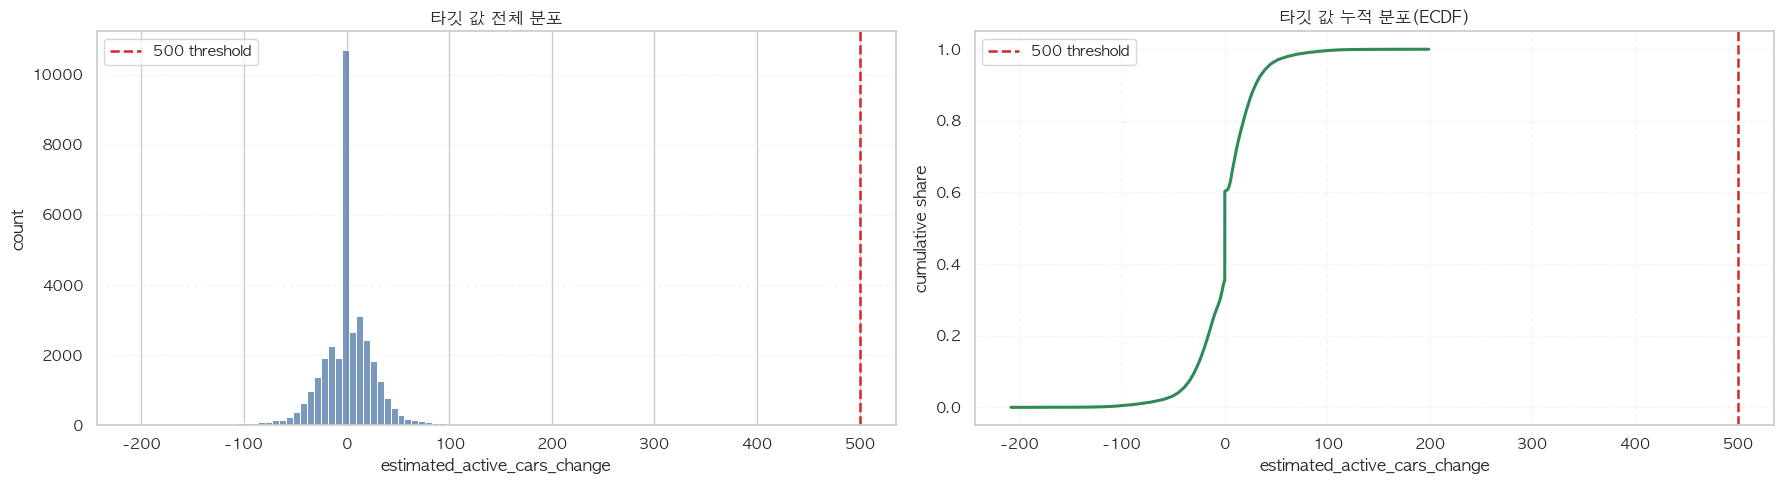

해석: 변화량 타깃은 0을 중심으로 증가(+)와 감소(-)가 함께 존재합니다.
따라서 변화량 모델에서는 비음수 제약보다, 방향성과 절대오차를 함께 해석하는 것이 더 중요합니다.


In [7]:
target_distribution_df = pd.DataFrame([
    {'segment': 'below_100', 'row_count': int((df[TARGET] < 100).sum()), 'share': float((df[TARGET] < 100).mean())},
    {'segment': '100_to_300', 'row_count': int(df[TARGET].between(100, 300, inclusive='left').sum()), 'share': float(df[TARGET].between(100, 300, inclusive='left').mean())},
    {'segment': '300_to_500', 'row_count': int(df[TARGET].between(300, 500, inclusive='left').sum()), 'share': float(df[TARGET].between(300, 500, inclusive='left').mean())},
    {'segment': '500_plus', 'row_count': int((df[TARGET] >= 500).sum()), 'share': float((df[TARGET] >= 500).mean())},
])

target_quantile_df = pd.DataFrame([
    {'percentile': label, 'value': float(df[TARGET].quantile(q))}
    for label, q in [('p50', 0.50), ('p75', 0.75), ('p90', 0.90), ('p95', 0.95), ('p99', 0.99)]
])

display(target_distribution_df)
display(target_quantile_df)

sorted_target = np.sort(df[TARGET].to_numpy(dtype=float))
ecdf = np.arange(1, len(sorted_target) + 1) / len(sorted_target)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.histplot(df[TARGET], bins=60, color='#4C78A8', ax=axes[0])
axes[0].axvline(500, color='#d62728', linestyle='--', linewidth=1.8, label='500 threshold')
axes[0].set_title('타깃 값 전체 분포')
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('count')
axes[0].legend(frameon=True)
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

axes[1].plot(sorted_target, ecdf, color='#2e8b57', linewidth=2.2)
axes[1].axvline(500, color='#d62728', linestyle='--', linewidth=1.8, label='500 threshold')
axes[1].set_title('타깃 값 누적 분포(ECDF)')
axes[1].set_xlabel(TARGET)
axes[1].set_ylabel('cumulative share')
axes[1].legend(frameon=True)
axes[1].grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print('해석: 변화량 타깃은 0을 중심으로 증가(+)와 감소(-)가 함께 존재합니다.')
print('따라서 변화량 모델에서는 비음수 제약보다, 방향성과 절대오차를 함께 해석하는 것이 더 중요합니다.')


## 6. 모델링에 쓰는 계산 규칙

이 노트북은 `year_weight`는 쓰지 않고, `month_weight + hour_weight` 중심 구조만 사용합니다.

이번 모델은 한 번에 모든 것을 맞추는 방식이 아니라, **기본 흐름을 먼저 회귀식으로 잡고, 그 다음 가중치로 보정하고, 마지막에 Ridge 회귀로 남은 차이를 설명하는 구조**입니다.

왜 이렇게 나누는가:

- 난지 주차 수요는 하루 안에서 반복되는 시간대 패턴이 큼
- 같은 시간대라도 계절과 월에 따라 전체 수준이 달라짐
- 날씨, 교통, 행사 같은 외부 변수는 이 기본 흐름 위에서 추가 차이를 만들 가능성이 큼
- 따라서 `기본 패턴 -> 월/시간 보정 -> 외부 변수 보정` 순서로 보는 편이 해석도 쉽고 누수도 막기 좋음

핵심 계산 흐름은 아래와 같습니다.

1. `요일 유형(평일/휴일) x 시간` 기준으로 기본 패턴 회귀식을 만든다.
2. 이 회귀식이 설명하지 못한 월별 평균 차이를 `month_weight`로 보정한다.
3. 운영시간 안에서 남아 있는 시간대별 차이를 `hour_weight`로 한 번 더 보정한다.
4. 이렇게 만든 `pattern_prior`, `corrected_pattern_prior`를 모델의 핵심 입력값으로 사용한다.
5. 마지막으로 Ridge 회귀가 외부 변수와 패턴 정보를 함께 보고 최종 예측값을 학습한다.

여기서 회귀식과 가중치의 역할은 조금 다릅니다.

- 회귀식: 하루 안에서 반복되는 부드러운 기본 모양을 학습
- `month_weight`: 월별로 전체 수요 수준이 얼마나 높거나 낮아지는지 반영
- `hour_weight`: 운영시간 안에서 특정 시간대가 기본 패턴보다 더 붐비거나 덜 붐비는지 반영
- Ridge 회귀: 위의 패턴 정보와 외부 변수를 같이 보고 최종 오차를 줄이는 역할

여기에 `hour_sin`, `hour_cos`, `month_sin`, `month_cos`를 쓰는 이유도 따로 있습니다.

- 시간과 월은 단순한 직선 숫자가 아니라 `23시 -> 0시`, `12월 -> 1월`처럼 다시 이어지는 주기 구조임
- `hour_weight`, `month_weight`만 쓰면 각 시간, 각 월의 크기 차이는 반영할 수 있지만, 이 값들이 원처럼 이어진다는 정보까지는 충분히 주기 어려움
- 반면 `sin / cos`는 시간과 월의 주기 모양을 부드럽게 표현해 주기 때문에, 인접한 시간대와 월이 자연스럽게 이어진다는 점을 모델에 알려 줄 수 있음

즉 `weight`는 **얼마나 크고 작은지**를 보정하는 값이고, `sin / cos`는 **주기가 어떻게 이어지는지**를 알려주는 값이라고 보면 됩니다. 그래서 `weighted_core`처럼 단순한 구조에서는 weight 중심으로도 충분히 갈 수 있지만, `weather_only_extended`나 `weighted_extended`처럼 확장된 모델에서는 `sin / cos`가 시간/계절 흐름을 더 매끈하게 설명하는 보조 역할을 합니다.


In [8]:
def non_negative_only(values: np.ndarray) -> np.ndarray:
    return np.asarray(values, dtype=float)


def enforce_operating_hours(frame: pd.DataFrame, preds: np.ndarray) -> np.ndarray:
    adjusted = np.asarray(preds, dtype=float).copy()
    adjusted[~frame['hour'].isin(OPERATING_HOURS).to_numpy()] = 0.0
    return adjusted


def calc_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def classify_boxplot_outliers(frame: pd.DataFrame, target: str, iqr_multiplier: float = 1.5):
    scored = frame.copy()
    target_series = scored[target].dropna()
    q1 = float(target_series.quantile(0.25))
    q3 = float(target_series.quantile(0.75))
    iqr = float(q3 - q1)
    upper_bound = float(q3 + iqr_multiplier * iqr)

    regular_mask = scored[target].le(upper_bound)
    if regular_mask.any():
        regular_max = float(scored.loc[regular_mask, target].max())
    else:
        regular_max = float(target_series.max())

    scored['outlier_candidate'] = scored[target] > upper_bound
    scored['comparison_anchor'] = regular_max
    scored['gap_from_anchor'] = 0.0
    scored['outlier_class'] = 'regular'

    candidate_indices = scored.index[scored['outlier_candidate']].tolist()
    ordered_indices = sorted(candidate_indices, key=lambda idx: float(scored.at[idx, target]))

    anchor = regular_max
    for idx in ordered_indices:
        value = float(scored.at[idx, target])
        gap = value - anchor
        scored.at[idx, 'comparison_anchor'] = anchor
        scored.at[idx, 'gap_from_anchor'] = gap

        if gap > iqr:
            scored.at[idx, 'outlier_class'] = 'outlier'
        else:
            scored.at[idx, 'outlier_class'] = 'special_case'
            anchor = value

    summary_df = pd.DataFrame([
        {
            'target': target,
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'upper_bound': upper_bound,
            'regular_max': regular_max,
            'candidate_count': int(scored['outlier_candidate'].sum()),
            'special_case_count': int(scored['outlier_class'].eq('special_case').sum()),
            'outlier_count': int(scored['outlier_class'].eq('outlier').sum()),
            'rule': '후보를 작은 값부터 순서대로 보며 직전 anchor와의 차이가 IQR보다 크면 이상치 제거, 아니면 특이치 유지 후 anchor 갱신',
        }
    ])
    return scored, summary_df






def assess_feature_normality(frame: pd.DataFrame, feature_columns: list[str], sample_size: int = 5000, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    rows = []

    for feature in feature_columns:
        series = frame[feature].dropna().astype(float)
        n = len(series)
        if n == 0:
            rows.append({
                'feature': feature,
                'n': 0,
                'nunique': 0,
                'zero_ratio': np.nan,
                'skewness': np.nan,
                'kurtosis': np.nan,
                'normaltest_pvalue': np.nan,
                'normality_class': 'empty',
                'normalization_need': 'skip',
                'decision_reason': '결측만 존재',
            })
            continue

        nunique = int(series.nunique())
        zero_ratio = float((series == 0).mean())
        sample = series if n <= sample_size else series.iloc[rng.choice(n, sample_size, replace=False)]
        try:
            normaltest_pvalue = float(stats.normaltest(sample).pvalue) if len(sample) >= 8 else np.nan
        except Exception:
            normaltest_pvalue = np.nan

        skewness = float(series.skew())
        kurtosis = float(series.kurt())
        is_sparse_or_discrete = zero_ratio >= 0.7 or (nunique <= 24 and np.allclose(series.to_numpy(dtype=float), np.round(series.to_numpy(dtype=float))))

        if is_sparse_or_discrete:
            normality_class = 'sparse_or_discrete'
            normalization_need = 'review_only_keep_raw'
            decision_reason = '희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼'
        elif abs(skewness) < 1 and abs(kurtosis) < 3 and (np.isnan(normaltest_pvalue) or normaltest_pvalue >= 0.05):
            normality_class = 'close_to_normal'
            normalization_need = 'standard_scaler_enough'
            decision_reason = '분포 왜곡이 크지 않아 현재 Ridge + StandardScaler로 충분'
        elif series.min() >= 0 and zero_ratio < 0.7 and abs(skewness) >= 1.5:
            normality_class = 'strong_right_skew'
            normalization_need = 'log1p_candidate'
            decision_reason = '양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음'
        else:
            normality_class = 'non_normal'
            normalization_need = 'standard_scaler_enough'
            decision_reason = '정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분'

        rows.append({
            'feature': feature,
            'n': n,
            'nunique': nunique,
            'zero_ratio': zero_ratio,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'normaltest_pvalue': normaltest_pvalue,
            'normality_class': normality_class,
            'normalization_need': normalization_need,
            'decision_reason': decision_reason,
        })

    normality_df = pd.DataFrame(rows)
    if not normality_df.empty:
        order = {
            'log1p_candidate': 0,
            'standard_scaler_enough': 1,
            'review_only_keep_raw': 2,
            'skip': 3,
        }
        normality_df['need_rank'] = normality_df['normalization_need'].map(order).fillna(9)
        normality_df = normality_df.sort_values(['need_rank', 'feature']).drop(columns=['need_rank']).reset_index(drop=True)
    return normality_df

def is_binary_indicator(series: pd.Series) -> bool:
    values = pd.Series(series.dropna().unique())
    if values.empty:
        return False
    try:
        numeric_values = values.astype(float)
    except (TypeError, ValueError):
        return False
    return set(np.round(numeric_values, 6)).issubset({0.0, 1.0})


def is_low_cardinality_integer(series: pd.Series, threshold: int = 24) -> bool:
    values = pd.Series(series.dropna())
    if values.empty or values.nunique() > threshold:
        return False
    numeric_values = pd.to_numeric(values, errors='coerce')
    if numeric_values.isna().any():
        return False
    numeric_array = numeric_values.to_numpy(dtype=float)
    return np.allclose(numeric_array, np.round(numeric_array))


def assess_ml_feature_outliers(frame: pd.DataFrame, feature_columns: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, list[int]]:
    audit_rows = []
    removed_detail_frames = []
    removed_indices = set()

    for feature in feature_columns:
        series = frame[feature]
        non_null = series.dropna()
        nunique = int(non_null.nunique())

        if non_null.empty:
            audit_rows.append({
                'feature': feature,
                'nunique': 0,
                'q1': np.nan,
                'q3': np.nan,
                'iqr': np.nan,
                'upper_bound': np.nan,
                'regular_max': np.nan,
                'candidate_count': 0,
                'special_case_count': 0,
                'outlier_count': 0,
                'action': 'skip_empty',
                'rationale': '결측만 존재해서 이상치 판정 대상에서 제외',
            })
            continue

        if is_binary_indicator(series):
            audit_rows.append({
                'feature': feature,
                'nunique': nunique,
                'q1': np.nan,
                'q3': np.nan,
                'iqr': np.nan,
                'upper_bound': np.nan,
                'regular_max': np.nan,
                'candidate_count': 0,
                'special_case_count': 0,
                'outlier_count': 0,
                'action': 'skip_binary_indicator',
                'rationale': '0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외',
            })
            continue

        q1 = float(non_null.quantile(0.25))
        q3 = float(non_null.quantile(0.75))
        iqr = float(q3 - q1)
        upper_bound = float(q3 + 1.5 * iqr)
        regular = non_null[non_null <= upper_bound]
        regular_max = float(regular.max()) if len(regular) else float(non_null.max())

        candidate_indices = frame.index[(series.notna()) & (series > upper_bound)].tolist()
        ordered_indices = sorted(candidate_indices, key=lambda idx: float(series.loc[idx]))
        anchor = regular_max
        special_case_indices = []
        outlier_indices = []
        anchor_map = {}
        gap_map = {}

        for idx in ordered_indices:
            value = float(series.loc[idx])
            gap = value - anchor
            anchor_map[idx] = anchor
            gap_map[idx] = gap

            if gap > iqr:
                outlier_indices.append(idx)
            else:
                special_case_indices.append(idx)
                anchor = value

        if iqr == 0:
            action = 'review_only_keep'
            rationale = 'IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 설명만 유지'
        elif is_low_cardinality_integer(series):
            action = 'review_only_keep'
            rationale = '저카디널리티 정수형/코드형 feature라 값 발생을 이상치보다 이벤트 신호로 해석'
        elif len(outlier_indices) > 0:
            action = 'remove_row'
            rationale = '연속형 규모 feature에서 anchor 기준으로 분리된 outlier가 확인되어 row 제거'
        else:
            action = 'keep'
            rationale = 'anchor 규칙상 제거할 outlier 없음'

        audit_rows.append({
            'feature': feature,
            'nunique': nunique,
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'upper_bound': upper_bound,
            'regular_max': regular_max,
            'candidate_count': len(candidate_indices),
            'special_case_count': len(special_case_indices),
            'outlier_count': len(outlier_indices),
            'action': action,
            'rationale': rationale,
        })

        if action == 'remove_row' and outlier_indices:
            detail_df = frame.loc[outlier_indices, ['datetime', 'split', feature]].copy()
            detail_df['feature'] = feature
            detail_df['row_index'] = detail_df.index
            detail_df['comparison_anchor'] = detail_df.index.map(anchor_map)
            detail_df['gap_from_anchor'] = detail_df.index.map(gap_map)
            detail_df = detail_df.rename(columns={feature: 'feature_value'})
            detail_df = detail_df[['feature', 'row_index', 'datetime', 'split', 'feature_value', 'comparison_anchor', 'gap_from_anchor']]
            removed_detail_frames.append(detail_df)
            removed_indices.update(outlier_indices)

    audit_df = pd.DataFrame(audit_rows)
    if not audit_df.empty:
        action_rank = {'remove_row': 0, 'review_only_keep': 1, 'keep': 2, 'skip_binary_indicator': 3, 'skip_empty': 4}
        audit_df['action_rank'] = audit_df['action'].map(action_rank).fillna(9)
        audit_df = audit_df.sort_values(['action_rank', 'outlier_count', 'candidate_count', 'feature'], ascending=[True, False, False, True]).drop(columns=['action_rank']).reset_index(drop=True)

    if removed_detail_frames:
        removed_rows_df = pd.concat(removed_detail_frames, ignore_index=True).sort_values(['feature', 'datetime']).reset_index(drop=True)
    else:
        removed_rows_df = pd.DataFrame(columns=['feature', 'row_index', 'datetime', 'split', 'feature_value', 'comparison_anchor', 'gap_from_anchor'])

    return audit_df, removed_rows_df, sorted(removed_indices)

def fit_day_type_hour_models(train_df: pd.DataFrame, target: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    formula_rows = []
    base_rows = []
    for day_type in DAY_TYPE_ORDER:
        sub = (
            train_df[train_df['day_type'] == day_type]
            .groupby('hour', as_index=False)[target]
            .mean()
            .sort_values('hour')
        )
        angle = 2 * np.pi * sub['hour'].to_numpy(dtype=float) / 24.0
        X = np.column_stack([np.ones(len(sub)), np.sin(angle), np.cos(angle)])
        y = sub[target].to_numpy(dtype=float)
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        sub['base_value'] = np.clip(X @ beta, 0, None)
        sub['day_type'] = day_type
        base_rows.append(sub[['day_type', 'hour', 'base_value']])
        formula_rows.append({
            'target': target,
            'day_type': day_type,
            'intercept': float(beta[0]),
            'sin_hour_coef': float(beta[1]),
            'cos_hour_coef': float(beta[2]),
            'formula': f'{beta[0]:.6f} + ({beta[1]:+.6f} * sin(2pi*hour/24)) + ({beta[2]:+.6f} * cos(2pi*hour/24))',
        })
    return pd.DataFrame(formula_rows), pd.concat(base_rows, ignore_index=True)


def shrink_late_hour_weight(hour_weight_map: dict[int, float], hour_base: pd.DataFrame, target_hour: int = 23, anchor_hour: int = 22) -> tuple[dict[int, float], pd.DataFrame]:
    adjusted = {int(k): float(v) for k, v in hour_weight_map.items()}
    diagnostics = []

    if target_hour not in adjusted or anchor_hour not in adjusted:
        return adjusted, pd.DataFrame(diagnostics)

    hour_target = hour_base[hour_base['hour'] == target_hour]['hour_ratio'].astype(float)
    if hour_target.empty:
        return adjusted, pd.DataFrame(diagnostics)

    raw_target = float(adjusted[target_hour])
    anchor = float(adjusted[anchor_hour])
    target_std = float(hour_target.std(ddof=1)) if len(hour_target) > 1 else 0.0
    target_mean = float(hour_target.mean())
    cv = target_std / max(abs(target_mean), 1e-6)
    reliability = 1.0 / (1.0 + cv)
    adjusted_target = reliability * raw_target + (1.0 - reliability) * anchor
    adjusted[target_hour] = float(adjusted_target)

    mean_after = float(np.mean(list(adjusted.values())))
    adjusted = {int(k): float(v / mean_after) for k, v in adjusted.items()}

    diagnostics.append({
        'target_hour': int(target_hour),
        'anchor_hour': int(anchor_hour),
        'raw_weight': raw_target,
        'anchor_weight': anchor,
        'adjusted_weight': float(adjusted[target_hour]),
        'hour_ratio_mean': target_mean,
        'hour_ratio_std': target_std,
        'hour_ratio_cv': float(cv),
        'reliability': float(reliability),
        'note': 'train hour_ratio variability based shrinkage; valid/test unused',
    })
    return adjusted, pd.DataFrame(diagnostics)


def build_weight_maps(all_df: pd.DataFrame, base_df: pd.DataFrame, target: str):
    all_base = all_df.merge(base_df, on=['day_type', 'hour'], how='left')
    all_base['month_ratio'] = np.where(all_base['base_value'] > 0, all_base[target] / all_base['base_value'], 1.0)
    month_weight_map = all_base.groupby('month')['month_ratio'].mean().to_dict()
    month_mean = float(np.mean(list(month_weight_map.values())))
    month_weight_map = {int(k): float(v / month_mean) for k, v in month_weight_map.items()}

    all_base['month_weight'] = all_base['month'].map(month_weight_map).fillna(1.0)
    all_base['pattern_prior'] = all_base['base_value'] * all_base['month_weight']
    hour_base = all_base[all_base['hour'].isin(OPERATING_HOURS)].copy()
    hour_base['hour_ratio'] = np.where(hour_base['pattern_prior'] > 0, hour_base[target] / hour_base['pattern_prior'], 1.0)
    raw_hour_weight_map = hour_base.groupby('hour')['hour_ratio'].mean().to_dict()
    hour_mean = float(np.mean(list(raw_hour_weight_map.values())))
    raw_hour_weight_map = {int(k): float(v / hour_mean) for k, v in raw_hour_weight_map.items()}
    hour_weight_map, hour_weight_adjustment_df = shrink_late_hour_weight(raw_hour_weight_map, hour_base, target_hour=23, anchor_hour=22)
    return month_weight_map, hour_weight_map, all_base, hour_weight_adjustment_df, raw_hour_weight_map


def attach_pattern_features(in_df: pd.DataFrame, base_df: pd.DataFrame, month_weight_map, hour_weight_map) -> pd.DataFrame:
    out = in_df.merge(base_df, on=['day_type', 'hour'], how='left')
    out['month_weight'] = out['month'].map(month_weight_map).fillna(1.0)
    out['pattern_prior'] = out['base_value'] * out['month_weight']
    out['hour_weight'] = out['hour'].map(hour_weight_map).fillna(1.0)
    out['corrected_pattern_prior'] = out['pattern_prior'] * out['hour_weight']
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24.0)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24.0)
    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12.0)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12.0)
    out['day_type_offday'] = out['day_type'].eq('offday').astype(int)
    return out.fillna(0)


def feature_sets() -> dict[str, list[str]]:
    core = [
        'base_value', 'month_weight', 'hour_weight',
        'pattern_prior', 'corrected_pattern_prior', 'day_type_offday',
    ]
    extended = core + [
        'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
        'is_holiday', 'is_long_weekend',
        'bus_boardings', 'bus_alightings', 'subway_boardings', 'subway_alightings',
        'bike_rentals', 'bike_returns', 'bike_rental_minutes_sum', 'bike_rental_distance_m_sum',
        'event_count', 'free_event_count', 'paid_event_count', 'evening_event_count',
        'bus_feature_available', 'subway_feature_available', 'bike_feature_available', 'culture_feature_available',
        *WEATHER_FEATURE_COLUMNS, 'weather_feature_available',
    ]
    return {'weighted_core': core, 'weighted_extended': extended}


def prune_correlated_features(train_df: pd.DataFrame, feature_map: dict[str, list[str]], threshold: float = 0.9):
    pruned_map = {}
    pruning_rows = []

    for model_name, columns in feature_map.items():
        corr = train_df[columns].corr().abs()
        target_corr = train_df[columns].corrwith(train_df[TARGET]).abs()
        kept = []
        dropped = set()

        for col in columns:
            if col in dropped:
                continue
            candidate = col
            for other in columns:
                if other == candidate or other in dropped or other in kept:
                    continue
                corr_value = corr.loc[candidate, other]
                if pd.notna(corr_value) and corr_value >= threshold:
                    if float(target_corr.get(other, 0.0)) > float(target_corr.get(candidate, 0.0)):
                        dropped.add(candidate)
                        pruning_rows.append({
                            'model_name': model_name,
                            'kept_feature': other,
                            'dropped_feature': candidate,
                            'abs_corr': float(corr_value),
                            'threshold': threshold,
                        })
                        candidate = other
                    else:
                        dropped.add(other)
                        pruning_rows.append({
                            'model_name': model_name,
                            'kept_feature': candidate,
                            'dropped_feature': other,
                            'abs_corr': float(corr_value),
                            'threshold': threshold,
                        })
            if candidate not in dropped and candidate not in kept:
                kept.append(candidate)

        pruned_map[model_name] = kept

    return pruned_map, pd.DataFrame(pruning_rows)


def prepare_split_frames(df: pd.DataFrame, base_df: pd.DataFrame, month_weight_map, hour_weight_map):
    processed = {}
    for split_name in ['train', 'valid', 'test']:
        part = df[df['split'] == split_name].copy()
        processed[split_name] = attach_pattern_features(part, base_df, month_weight_map, hour_weight_map)
    return processed


def fit_best_ridge_model(processed_splits: dict[str, pd.DataFrame], columns: list[str], sample_weight: np.ndarray | None = None):
    best_alpha = None
    best_model = None
    best_valid_rmse = math.inf

    X_train = processed_splits['train'][columns]
    y_train = processed_splits['train'][TARGET]
    X_valid = processed_splits['valid'][columns]
    y_valid = processed_splits['valid'][TARGET]

    for alpha in ALPHA_GRID:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha)),
        ])
        fit_kwargs = {}
        if sample_weight is not None:
            fit_kwargs['ridge__sample_weight'] = sample_weight
        model.fit(X_train, y_train, **fit_kwargs)
        valid_pred = non_negative_only(model.predict(X_valid))
        valid_pred = enforce_operating_hours(processed_splits['valid'], valid_pred)
        metrics = calc_metrics(y_valid, valid_pred)
        if metrics['rmse'] < best_valid_rmse:
            best_valid_rmse = metrics['rmse']
            best_alpha = alpha
            best_model = model

    return best_alpha, best_model
def train_models(processed_splits: dict[str, pd.DataFrame], feature_map: dict[str, list[str]]):
    tuning_rows = []
    metric_rows = []
    importance_rows = []

    for model_name, columns in feature_map.items():
        best_alpha = None
        best_model = None
        best_valid_rmse = math.inf

        X_train = processed_splits['train'][columns]
        y_train = processed_splits['train'][TARGET]
        X_valid = processed_splits['valid'][columns]
        y_valid = processed_splits['valid'][TARGET]

        for alpha in ALPHA_GRID:
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('ridge', Ridge(alpha=alpha)),
            ])
            model.fit(X_train, y_train)
            valid_pred = non_negative_only(model.predict(X_valid))
            valid_pred = enforce_operating_hours(processed_splits['valid'], valid_pred)
            metrics = calc_metrics(y_valid, valid_pred)
            tuning_rows.append({'model_name': model_name, 'alpha': alpha, **metrics})
            if metrics['rmse'] < best_valid_rmse:
                best_valid_rmse = metrics['rmse']
                best_alpha = alpha
                best_model = model

        scaler = best_model.named_steps['scaler']
        ridge = best_model.named_steps['ridge']
        scaled_coefs = ridge.coef_ / scaler.scale_
        coef_abs_sum = float(np.abs(scaled_coefs).sum())
        for feature, coef in zip(columns, scaled_coefs):
            importance_rows.append({
                'model_name': model_name,
                'feature': feature,
                'alpha': best_alpha,
                'coefficient': float(coef),
                'importance_abs': float(abs(coef)),
                'importance_ratio': float(abs(coef) / coef_abs_sum) if coef_abs_sum else 0.0,
            })

        for split_name in ['train', 'valid', 'test']:
            frame = processed_splits[split_name]
            pred = non_negative_only(best_model.predict(frame[columns]))
            pred = enforce_operating_hours(frame, pred)
            processed_splits[split_name][f'{model_name}_prediction'] = pred
            metric_rows.append({'model_name': model_name, 'alpha': best_alpha, 'split': split_name, **calc_metrics(frame[TARGET], pred)})

    return pd.DataFrame(tuning_rows), pd.DataFrame(metric_rows), pd.DataFrame(importance_rows)


## 7. 데이터 품질과 feature 가용성 점검

모델링 전에 다음을 확인합니다.

- 시간 중복 여부
- 타깃 결측 여부
- 외생 변수 가용률
- split 구간별 행 수



In [9]:
quality_df = pd.DataFrame([
    {
        'rows': len(df),
        'unique_datetime': df['datetime'].nunique(),
        'duplicate_rows': int(len(df) - df['datetime'].nunique()),
        'target_missing': int(df[TARGET].isna().sum()),
        'target_min': float(df[TARGET].min()),
        'target_max': float(df[TARGET].max()),
        'date_min': df['datetime'].min(),
        'date_max': df['datetime'].max(),
    }
])

coverage_df = (
    df[['bus_feature_available', 'subway_feature_available', 'bike_feature_available', 'culture_feature_available', 'weather_feature_available']]
    .mean()
    .rename('coverage_rate')
    .reset_index()
    .rename(columns={'index': 'feature'})
)

missing_df = (
    df.isna().sum()
    .sort_values(ascending=False)
    .rename('missing_count')
    .reset_index()
    .rename(columns={'index': 'feature'})
    .head(12)
)

split_summary = (
    df.groupby('split', as_index=False)
    .agg(
        rows=('datetime', 'size'),
        date_min=('datetime', 'min'),
        date_max=('datetime', 'max'),
        target_mean=(TARGET, 'mean'),
    )
)

display(quality_df)
display(coverage_df)
display(missing_df)
display(split_summary)



,rows,unique_datetime,duplicate_rows,target_missing,target_min,target_max,date_min,date_max
0,34920,34920,0,0,-208.326398,198.8922,2022-01-01,2025-12-31 23:00:00


,feature,coverage_rate
0,bus_feature_available,0.719903
1,subway_feature_available,0.924456
2,bike_feature_available,0.331959
3,culture_feature_available,0.187629
4,weather_feature_available,1.000000


,feature,missing_count
0,holiday_name,33144
1,bus_boardings,9781
2,bus_alightings,9781
3,dew_point_2m,0
4,snowfall,0
5,rain,0
6,precipitation,0
7,apparent_temperature,0
8,relative_humidity_2m,0
9,weather_code,0


,split,rows,date_min,date_max,target_mean
0,test,8760,2025-01-01,2025-12-31 23:00:00,0.908753
1,train,17400,2022-01-01,2023-12-31 23:00:00,0.919086
2,valid,8760,2024-01-01,2024-12-31 23:00:00,0.843557


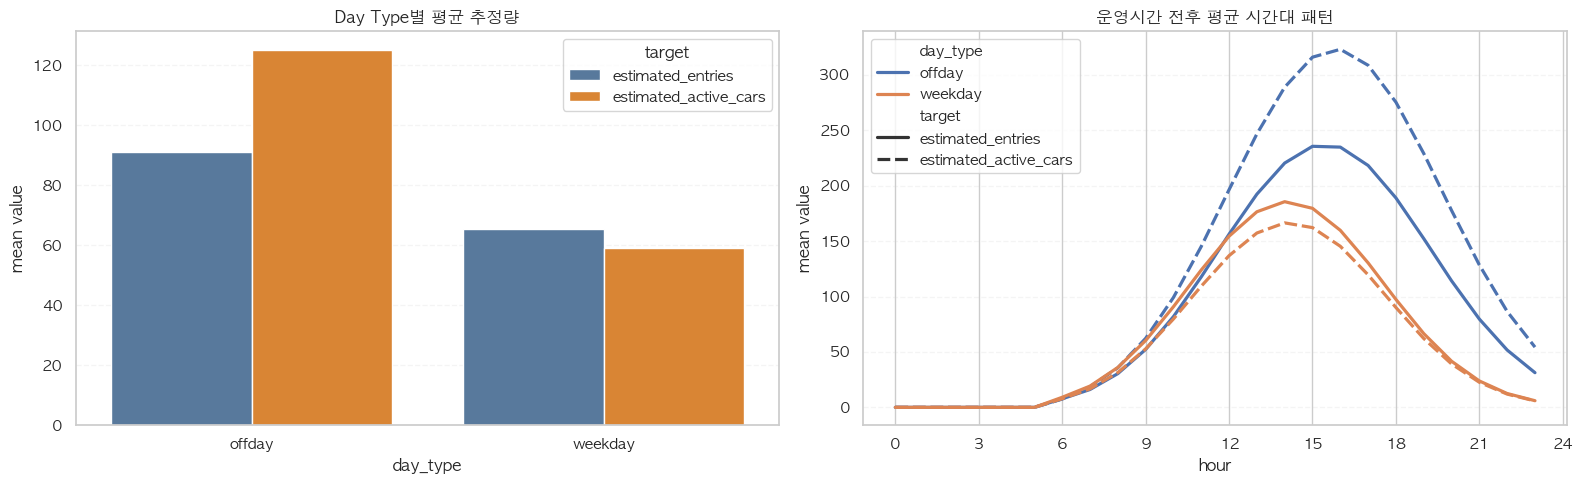

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_type_summary = (
    df.groupby('day_type', as_index=False)[['estimated_entries', 'estimated_active_cars']]
    .mean()
    .melt(id_vars='day_type', var_name='target', value_name='mean_value')
)
sns.barplot(data=day_type_summary, x='day_type', y='mean_value', hue='target', ax=axes[0], palette=['#4C78A8', '#F58518'])
axes[0].set_title('Day Type별 평균 추정량')
axes[0].set_xlabel('day_type')
axes[0].set_ylabel('mean value')
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

hourly_profile = (
    df.groupby(['day_type', 'hour'], as_index=False)[['estimated_entries', 'estimated_active_cars']]
    .mean()
    .melt(id_vars=['day_type', 'hour'], var_name='target', value_name='mean_value')
)
sns.lineplot(data=hourly_profile, x='hour', y='mean_value', hue='day_type', style='target', linewidth=2.3, ax=axes[1])
axes[1].set_title('운영시간 전후 평균 시간대 패턴')
axes[1].set_xlabel('hour')
axes[1].set_ylabel('mean value')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


### 추가 시각화: 데이터 범위와 시기별 수요 흐름

아래 그림은 `train / valid / test` 구간이 시간축에서 어떻게 이어지는지, 그리고 시기별 평균 주차 수요가 어떻게 움직이는지를 더 직관적으로 보여줍니다.

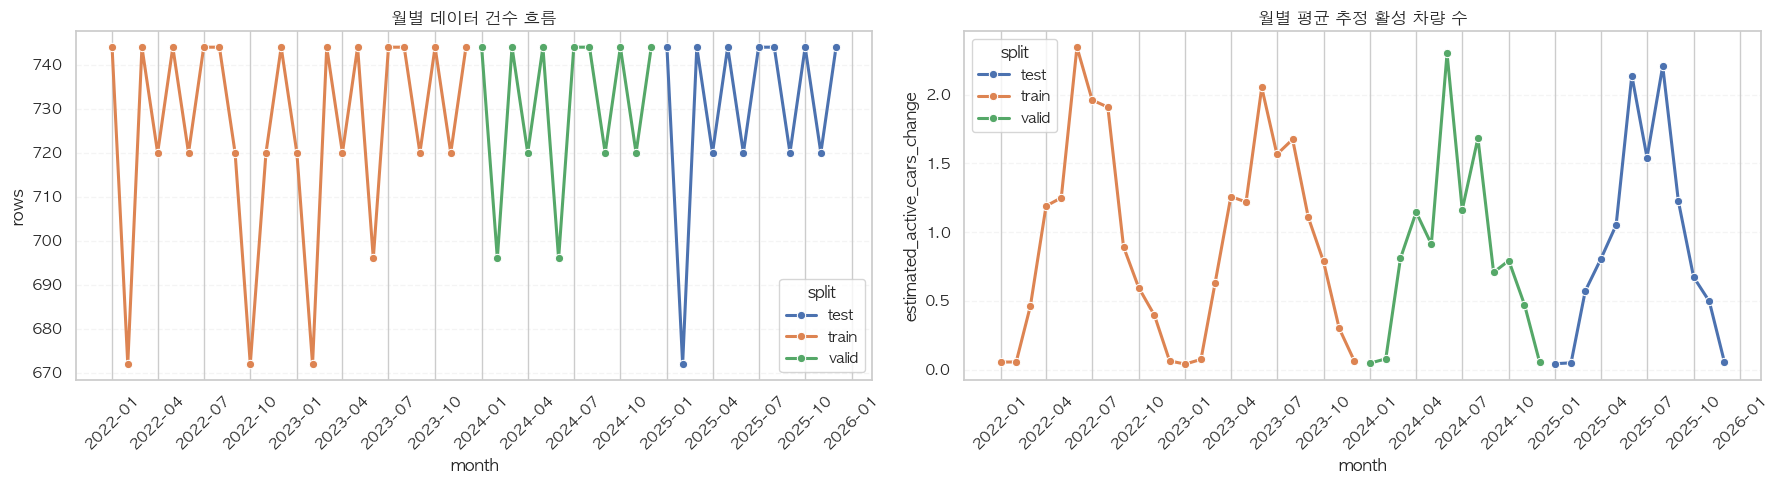

In [11]:
monthly_split_view = (
    df.assign(month_start=df['datetime'].dt.to_period('M').dt.to_timestamp())
    .groupby(['split', 'month_start'], as_index=False)
    .agg(
        rows=('datetime', 'size'),
        mean_target=(TARGET, 'mean'),
        mean_entries=('estimated_entries', 'mean'),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.lineplot(data=monthly_split_view, x='month_start', y='rows', hue='split', marker='o', linewidth=2.2, ax=axes[0])
axes[0].set_title('월별 데이터 건수 흐름')
axes[0].set_xlabel('month')
axes[0].set_ylabel('rows')
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.lineplot(data=monthly_split_view, x='month_start', y='mean_target', hue='split', marker='o', linewidth=2.2, ax=axes[1])
axes[1].set_title('월별 평균 추정 활성 차량 수')
axes[1].set_xlabel('month')
axes[1].set_ylabel(TARGET)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()


## 7-1. 입력 변수 분포 점검과 추가 변환 필요 여부 확인

이상값을 보기 전에, 먼저 모델에 들어갈 값들의 분포가 한쪽으로 너무 쏠려 있는지, 그리고 별도의 변환이 필요한지를 확인합니다.

여기서는 아래 내용을 같이 봅니다.

- 값이 한쪽으로 심하게 몰려 있는지
- 값의 퍼짐 모양이 너무 뾰족하거나 치우쳐 있는지
- 대부분이 0이고 가끔만 값이 생기는 변수인지
- 현재 Ridge + `StandardScaler` 구조에서 추가 변환이 꼭 필요한지

이 단계의 목적은 “모든 변수를 완벽하게 종 모양 분포로 만들기”가 아니라, **지금 모델 구조에서 굳이 로그변환 같은 추가 작업이 필요한 변수가 있는지 미리 확인하는 것**입니다.


In [12]:
from scipy import stats

if 'assess_feature_normality' not in globals():
    def assess_feature_normality(frame: pd.DataFrame, feature_columns: list[str], sample_size: int = 5000, random_state: int = 42) -> pd.DataFrame:
        rng = np.random.default_rng(random_state)
        rows = []

        for feature in feature_columns:
            series = frame[feature].dropna().astype(float)
            n = len(series)
            if n == 0:
                rows.append({
                    'feature': feature,
                    'n': 0,
                    'nunique': 0,
                    'zero_ratio': np.nan,
                    'skewness': np.nan,
                    'kurtosis': np.nan,
                    'normaltest_pvalue': np.nan,
                    'normality_class': 'empty',
                    'normalization_need': 'skip',
                    'decision_reason': '결측만 존재',
                })
                continue

            nunique = int(series.nunique())
            zero_ratio = float((series == 0).mean())
            sample = series if n <= sample_size else series.iloc[rng.choice(n, sample_size, replace=False)]
            try:
                normaltest_pvalue = float(stats.normaltest(sample).pvalue) if len(sample) >= 8 else np.nan
            except Exception:
                normaltest_pvalue = np.nan

            skewness = float(series.skew())
            kurtosis = float(series.kurt())
            is_sparse_or_discrete = zero_ratio >= 0.7 or (nunique <= 24 and np.allclose(series.to_numpy(dtype=float), np.round(series.to_numpy(dtype=float))))

            if is_sparse_or_discrete:
                normality_class = 'sparse_or_discrete'
                normalization_need = 'review_only_keep_raw'
                decision_reason = '희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼'
            elif abs(skewness) < 1 and abs(kurtosis) < 3 and (np.isnan(normaltest_pvalue) or normaltest_pvalue >= 0.05):
                normality_class = 'close_to_normal'
                normalization_need = 'standard_scaler_enough'
                decision_reason = '분포 왜곡이 크지 않아 현재 Ridge + StandardScaler로 충분'
            elif series.min() >= 0 and zero_ratio < 0.7 and abs(skewness) >= 1.5:
                normality_class = 'strong_right_skew'
                normalization_need = 'log1p_candidate'
                decision_reason = '양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음'
            else:
                normality_class = 'non_normal'
                normalization_need = 'standard_scaler_enough'
                decision_reason = '정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분'

            rows.append({
                'feature': feature,
                'n': n,
                'nunique': nunique,
                'zero_ratio': zero_ratio,
                'skewness': skewness,
                'kurtosis': kurtosis,
                'normaltest_pvalue': normaltest_pvalue,
                'normality_class': normality_class,
                'normalization_need': normalization_need,
                'decision_reason': decision_reason,
            })

        normality_df = pd.DataFrame(rows)
        if not normality_df.empty:
            order = {
                'log1p_candidate': 0,
                'standard_scaler_enough': 1,
                'review_only_keep_raw': 2,
                'skip': 3,
            }
            normality_df['need_rank'] = normality_df['normalization_need'].map(order).fillna(9)
            normality_df = normality_df.sort_values(['need_rank', 'feature']).drop(columns=['need_rank']).reset_index(drop=True)
        return normality_df

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

normality_review_columns = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'bus_boardings', 'bus_alightings', 'subway_boardings', 'subway_alightings',
    'bike_rentals', 'bike_returns', 'bike_rental_minutes_sum', 'bike_rental_distance_m_sum',
    'event_count', 'free_event_count', 'paid_event_count', 'evening_event_count',
    *WEATHER_FEATURE_COLUMNS,
    TARGET,
]

feature_normality_df = assess_feature_normality(df, normality_review_columns)
normality_summary = (
    feature_normality_df.groupby(['normalization_need', 'normality_class'], as_index=False)
    .agg(feature_count=('feature', 'size'))
    .sort_values(['normalization_need', 'normality_class'])
)
log_candidate_df = feature_normality_df[feature_normality_df['normalization_need'] == 'log1p_candidate'].copy()
standard_only_df = feature_normality_df[feature_normality_df['normalization_need'] == 'standard_scaler_enough'].copy()
sparse_review_df = feature_normality_df[feature_normality_df['normalization_need'] == 'review_only_keep_raw'].copy()

display(normality_summary)
display(feature_normality_df[['feature', 'zero_ratio', 'skewness', 'kurtosis', 'normaltest_pvalue', 'normality_class', 'normalization_need', 'decision_reason']])
display(log_candidate_df[['feature', 'zero_ratio', 'skewness', 'kurtosis', 'decision_reason']])
display(standard_only_df[['feature', 'zero_ratio', 'skewness', 'kurtosis', 'decision_reason']].head(12))
display(sparse_review_df[['feature', 'zero_ratio', 'skewness', 'kurtosis', 'decision_reason']])

print('정리:')
print('- 현재 Ridge 파이프라인에는 이미 StandardScaler가 들어 있으므로 scale 정규화는 기본적으로 수행됩니다.')
print('- 이번 점검에서는 bike_rentals, bike_returns, bike_rental_minutes_sum, bike_rental_distance_m_sum, direct_radiation, estimated_active_cars가 log1p 후보로 확인됐습니다.')
print('- 다만 노트북의 기존 프로세스를 유지하기 위해 이번 버전에서는 별도 로그변환을 적용하지 않고, 필요 후보만 설명으로 남깁니다.')


,normalization_need,normality_class,feature_count
0,log1p_candidate,strong_right_skew,5
1,review_only_keep_raw,sparse_or_discrete,9
2,standard_scaler_enough,non_normal,25


,feature,zero_ratio,skewness,kurtosis,normaltest_pvalue,normality_class,normalization_need,decision_reason
0,bike_rental_distance_m_sum,0.668041,3.267935e+00,12.300657,0.000000e+00,strong_right_skew,log1p_candidate,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
1,bike_rental_minutes_sum,0.668041,3.345097e+00,13.390102,0.000000e+00,strong_right_skew,log1p_candidate,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
2,bike_rentals,0.668041,2.671610e+00,7.693105,0.000000e+00,strong_right_skew,log1p_candidate,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
3,bike_returns,0.667784,2.635156e+00,7.312307,0.000000e+00,strong_right_skew,log1p_candidate,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
4,direct_radiation,0.538631,1.756389e+00,1.992531,0.000000e+00,strong_right_skew,log1p_candidate,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
5,apparent_temperature,0.002033,-5.331929e-02,-1.122617,0.000000e+00,non_normal,standard_scaler_enough,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
6,bus_alightings,0.000000,-1.885574e-01,-0.856413,7.281343e-116,non_normal,standard_scaler_enough,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
7,bus_boardings,0.000000,-1.178673e-01,-0.797173,5.812571e-100,non_normal,standard_scaler_enough,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
8,cloud_cover,0.234937,-1.597688e-01,-1.809629,0.000000e+00,non_normal,standard_scaler_enough,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
9,cloud_cover_high,0.483935,5.320412e-01,-1.601116,0.000000e+00,non_normal,standard_scaler_enough,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분


,feature,zero_ratio,skewness,kurtosis,decision_reason
0,bike_rental_distance_m_sum,0.668041,3.267935,12.300657,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
1,bike_rental_minutes_sum,0.668041,3.345097,13.390102,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
2,bike_rentals,0.668041,2.671610,7.693105,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
3,bike_returns,0.667784,2.635156,7.312307,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음
4,direct_radiation,0.538631,1.756389,1.992531,양수 기반 강한 우측 왜도라 필요시 log1p 변환을 검토할 수 있음


,feature,zero_ratio,skewness,kurtosis,decision_reason
5,apparent_temperature,0.002033,-5.331929e-02,-1.122617,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
6,bus_alightings,0.000000,-1.885574e-01,-0.856413,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
7,bus_boardings,0.000000,-1.178673e-01,-0.797173,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
8,cloud_cover,0.234937,-1.597688e-01,-1.809629,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
9,cloud_cover_high,0.483935,5.320412e-01,-1.601116,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
10,cloud_cover_low,0.506128,1.393950e+00,0.229325,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
11,cloud_cover_mid,0.529725,1.313257e+00,-0.017352,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
12,dew_point_2m,0.001375,-3.326981e-01,-0.843559,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
13,diffuse_radiation,0.464261,1.232312e+00,0.695303,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분
14,estimated_active_cars_change,0.250000,-1.810831e-01,4.235183,정규분포는 아니지만 현재 Ridge에서는 표준화만으로도 실무상 충분


,feature,zero_ratio,skewness,kurtosis,decision_reason
30,evening_event_count,0.815808,2.432310,4.918700,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
31,event_count,0.812371,2.171849,3.324472,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
32,free_event_count,0.812371,2.188404,3.376076,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
33,paid_event_count,0.878351,3.075274,9.463216,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
34,precipitation,0.854725,10.730858,171.563169,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
35,rain,0.862858,10.813344,173.437989,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
36,snow_depth,0.863574,4.490752,26.509848,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
37,snowfall,0.989089,21.202857,563.907375,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼
38,weather_code,0.370046,2.070633,2.492527,희소/이산형 feature라 정규분포 판단보다 발생 자체의 의미가 더 큼


정리:
- 현재 Ridge 파이프라인에는 이미 StandardScaler가 들어 있으므로 scale 정규화는 기본적으로 수행됩니다.
- 이번 점검에서는 bike_rentals, bike_returns, bike_rental_minutes_sum, bike_rental_distance_m_sum, direct_radiation, estimated_active_cars가 log1p 후보로 확인됐습니다.
- 다만 노트북의 기존 프로세스를 유지하기 위해 이번 버전에서는 별도 로그변환을 적용하지 않고, 필요 후보만 설명으로 남깁니다.


## 7-2. 타깃 값의 이상값/특이값 점검

입력 변수 분포를 본 다음에는, 예측 대상인 `estimated_active_cars` 값에서 너무 튀는 값이 있는지 확인합니다.

이번 노트북에서는 먼저 boxplot 기준인 `Q3 + 1.5*IQR`보다 큰 값을 **후보**로 잡고, 그 다음 아래 규칙으로 `이상값`과 `특이값`을 구분합니다.

- 첫 번째 후보는 `일반 구간 최대값`과 얼마나 차이 나는지 확인
- 어떤 후보가 `특이값`으로 남으면, 다음 후보는 `일반 구간 최대값`이 아니라 **직전 특이값**과 비교
- 이렇게 작은 값부터 순서대로 보면서 차이가 `IQR`보다 크면 `이상값`
- 차이가 `IQR` 이하이면 `특이값`
- `이상값`은 학습 전에 제거
- `특이값`은 실제 피크일 수 있으므로 설명만 남기고 유지

즉, 값이 높다고 무조건 지우지 않고, **앞의 흐름과 비교했을 때 갑자기 크게 튀는 경우만 이상값**으로 봅니다.


,target,q1,q3,iqr,upper_bound,regular_max,candidate_count,special_case_count,outlier_count,rule
0,estimated_active_cars_change,-10.962729,13.742688,24.705417,50.800812,50.799804,1069,1069,0,후보를 작은 값부터 순서대로 보며 직전 anchor와의 차이가 IQR보다 크면 이상...


,outlier_class,row_count,min_value,median_value,max_value,mean_gap_from_anchor
0,special_case,1069,50.808563,68.558974,198.8922,0.138534


,split,rows,removed_outliers,kept_special_cases
0,test,8760,0,262
1,train,17400,0,550
2,valid,8760,0,257


,datetime,split,hour,estimated_active_cars_change,comparison_anchor,gap_from_anchor,outlier_class
0,2025-07-12 12:00:00,test,12,50.808563,50.799804,0.008759,special_case
1,2025-08-30 13:00:00,test,13,50.821012,50.808563,0.012449,special_case
2,2024-10-06 12:00:00,valid,12,50.835863,50.821012,0.014851,special_case
3,2025-09-25 10:00:00,test,10,50.865948,50.835863,0.030085,special_case
4,2022-03-27 14:00:00,train,14,50.875067,50.865948,0.009119,special_case
5,2025-08-16 16:00:00,test,16,50.878851,50.875067,0.003785,special_case
6,2022-04-09 10:00:00,train,10,50.949803,50.878851,0.070952,special_case
7,2024-10-25 11:00:00,valid,11,50.963871,50.949803,0.014068,special_case
8,2022-08-14 14:00:00,train,14,51.009686,50.963871,0.045815,special_case
9,2025-10-24 11:00:00,test,11,51.012885,51.009686,0.003199,special_case


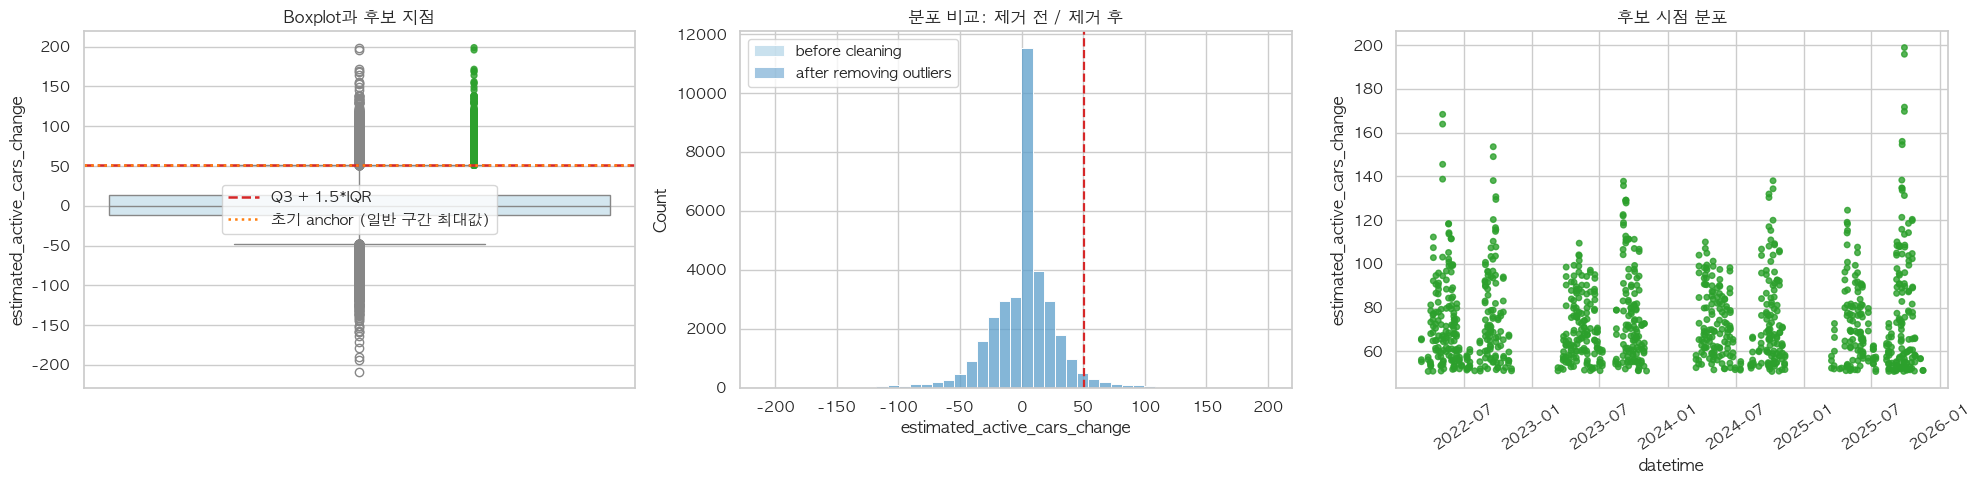

특이치는 설명을 위해 유지하고, 이상치만 제거합니다.
제거되는 이상치 행 수: 0
유지되는 특이치 행 수: 1069


,split,rows,start_datetime,end_datetime,unique_days
0,test,8760,2025-01-01,2025-12-31 23:00:00,365
1,train,17400,2022-01-01,2023-12-31 23:00:00,725
2,valid,8760,2024-01-01,2024-12-31 23:00:00,365


In [13]:
classified_df, outlier_rule_df = classify_boxplot_outliers(df, TARGET)
candidate_df = (
    classified_df[classified_df['outlier_candidate']]
    .sort_values(TARGET)
    .reset_index(drop=True)
)
removed_outliers_df = candidate_df[candidate_df['outlier_class'] == 'outlier'].copy()
special_cases_df = candidate_df[candidate_df['outlier_class'] == 'special_case'].copy()

outlier_class_summary = (
    candidate_df.groupby('outlier_class', as_index=False)
    .agg(
        row_count=('datetime', 'size'),
        min_value=(TARGET, 'min'),
        median_value=(TARGET, 'median'),
        max_value=(TARGET, 'max'),
        mean_gap_from_anchor=('gap_from_anchor', 'mean'),
    )
    .sort_values(['outlier_class'])
)
outlier_split_summary = (
    classified_df.assign(
        is_outlier=classified_df['outlier_class'].eq('outlier').astype(int),
        is_special_case=classified_df['outlier_class'].eq('special_case').astype(int),
    )
    .groupby('split', as_index=False)
    .agg(
        rows=('datetime', 'size'),
        removed_outliers=('is_outlier', 'sum'),
        kept_special_cases=('is_special_case', 'sum'),
    )
)
outlier_examples = candidate_df[
    ['datetime', 'split', 'hour', TARGET, 'comparison_anchor', 'gap_from_anchor', 'outlier_class']
].head(20)

display(outlier_rule_df)
display(outlier_class_summary)
display(outlier_split_summary)
display(outlier_examples)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.boxplot(y=classified_df[TARGET], ax=axes[0], color='#cfe8f3', width=0.35)
axes[0].axhline(outlier_rule_df.loc[0, 'upper_bound'], color='#d62728', linestyle='--', linewidth=1.8, label='Q3 + 1.5*IQR')
axes[0].axhline(outlier_rule_df.loc[0, 'regular_max'], color='#ff7f0e', linestyle=':', linewidth=1.8, label='초기 anchor (일반 구간 최대값)')
if not candidate_df.empty:
    x_positions = np.where(candidate_df['outlier_class'].eq('outlier'), -0.08, 0.08)
    candidate_colors = candidate_df['outlier_class'].map({'outlier': '#d62728', 'special_case': '#2ca02c'})
    axes[0].scatter(x_positions, candidate_df[TARGET], c=candidate_colors, alpha=0.8, s=18)
axes[0].set_title('Boxplot과 후보 지점')
axes[0].set_ylabel(TARGET)
axes[0].set_xticks([])
axes[0].legend(frameon=True)

sns.histplot(classified_df[TARGET], bins=45, color='#9ecae1', alpha=0.55, label='before cleaning', ax=axes[1])
sns.histplot(classified_df.loc[classified_df['outlier_class'] != 'outlier', TARGET], bins=45, color='#3182bd', alpha=0.45, label='after removing outliers', ax=axes[1])
axes[1].axvline(outlier_rule_df.loc[0, 'upper_bound'], color='#d62728', linestyle='--', linewidth=1.6)
axes[1].set_title('분포 비교: 제거 전 / 제거 후')
axes[1].set_xlabel(TARGET)
axes[1].legend(frameon=True)

if not candidate_df.empty:
    time_colors = candidate_df['outlier_class'].map({'outlier': '#d62728', 'special_case': '#2ca02c'})
    axes[2].scatter(candidate_df['datetime'], candidate_df[TARGET], c=time_colors, alpha=0.8, s=16)
axes[2].set_title('후보 시점 분포')
axes[2].set_xlabel('datetime')
axes[2].set_ylabel(TARGET)
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

print('특이치는 설명을 위해 유지하고, 이상치만 제거합니다.')
print('제거되는 이상치 행 수:', len(removed_outliers_df))
print('유지되는 특이치 행 수:', len(special_cases_df))

df = (
    classified_df[classified_df['outlier_class'] != 'outlier']
    .drop(columns=['outlier_candidate', 'comparison_anchor', 'gap_from_anchor', 'outlier_class'])
    .reset_index(drop=True)
)

cleaned_split_summary = (
    df.groupby('split', as_index=False)
    .agg(
        rows=('datetime', 'size'),
        start_datetime=('datetime', 'min'),
        end_datetime=('datetime', 'max'),
        unique_days=('date', 'nunique'),
    )
)
display(cleaned_split_summary)


## 7-3. 모델 입력 변수의 이상값 점검

타깃 값뿐 아니라, 실제 머신러닝에 넣는 입력 변수들도 같은 기준으로 다시 확인합니다.

다만 모든 변수를 똑같이 처리하면 오히려 중요한 신호를 지워버릴 수 있어서 아래처럼 나눠 봅니다.

- `0/1 표시 변수`: 이상값 제거 대상에서 제외
- `드물게만 값이 생기는 변수`: 값이 생긴 것 자체가 의미일 수 있으므로 설명만 남기고 유지
- `연속적인 크기형 변수`: 흐름에서 크게 튀는 값이 있으면 제거 검토

또한 `base_value`, `month_weight`, `hour_weight`, `pattern_prior`, `corrected_pattern_prior`처럼 학습 과정에서 새로 계산되는 값은 원자료가 아니므로, 이 단계의 제거 대상에서는 제외합니다.


,action,feature_count,total_candidate_count,total_outlier_count
0,keep,27,32433,0
1,remove_row,2,12748,12
2,review_only_keep,9,43868,43868
3,skip_binary_indicator,7,0,0


,feature,feature_group,candidate_count,special_case_count,outlier_count,action,rationale
0,bike_rental_minutes_sum,bike,6477,6470,7,remove_row,연속형 규모 feature에서 anchor 기준으로 분리된 outlier가 확인되어...
1,bike_rental_distance_m_sum,bike,6271,6266,5,remove_row,연속형 규모 feature에서 anchor 기준으로 분리된 outlier가 확인되어...
2,event_count,event,6552,0,6552,review_only_keep,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
3,free_event_count,event,6552,0,6552,review_only_keep,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
4,evening_event_count,event,6432,0,6432,review_only_keep,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
5,weather_code,weather,5077,0,5077,review_only_keep,저카디널리티 정수형/코드형 feature라 값 발생을 이상치보다 이벤트 신호로 해석
6,precipitation,weather,5073,0,5073,review_only_keep,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
7,rain,weather,4789,0,4789,review_only_keep,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
8,snow_depth,weather,4764,0,4764,review_only_keep,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
9,paid_event_count,event,4248,0,4248,review_only_keep,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...


,feature,feature_group,candidate_count,special_case_count,outlier_count,rationale
0,bike_rental_minutes_sum,bike,6477,6470,7,연속형 규모 feature에서 anchor 기준으로 분리된 outlier가 확인되어...
1,bike_rental_distance_m_sum,bike,6271,6266,5,연속형 규모 feature에서 anchor 기준으로 분리된 outlier가 확인되어...


,feature,feature_group,candidate_count,special_case_count,outlier_count,rationale
2,event_count,event,6552,0,6552,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
3,free_event_count,event,6552,0,6552,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
4,evening_event_count,event,6432,0,6432,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
5,weather_code,weather,5077,0,5077,저카디널리티 정수형/코드형 feature라 값 발생을 이상치보다 이벤트 신호로 해석
6,precipitation,weather,5073,0,5073,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
7,rain,weather,4789,0,4789,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
8,snow_depth,weather,4764,0,4764,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
9,paid_event_count,event,4248,0,4248,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...
10,snowfall,weather,381,0,381,IQR이 0이라 non-zero 발생 자체를 이상치로 보기 쉬워 row 제거 대신 ...


,feature,feature_group,action,rationale
38,bike_feature_available,availability_flag,skip_binary_indicator,0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외
39,bus_feature_available,availability_flag,skip_binary_indicator,0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외
40,culture_feature_available,availability_flag,skip_binary_indicator,0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외
41,is_holiday,calendar,skip_binary_indicator,0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외
42,is_long_weekend,calendar,skip_binary_indicator,0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외
43,subway_feature_available,availability_flag,skip_binary_indicator,0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외
44,weather_feature_available,availability_flag,skip_binary_indicator,0/1 indicator는 발생 여부 자체가 의미라 이상치 제거 대상에서 제외


,feature,row_index,datetime,split,feature_value,comparison_anchor,gap_from_anchor
0,bike_rental_distance_m_sum,10890,2023-04-03 18:00:00,train,6312020.75,6005430.57,306590.18
1,bike_rental_distance_m_sum,19407,2024-03-24 15:00:00,valid,6715044.93,6005430.57,709614.36
2,bike_rental_distance_m_sum,19408,2024-03-24 16:00:00,valid,6620197.35,6005430.57,614766.78
3,bike_rental_distance_m_sum,19743,2024-04-07 15:00:00,valid,6618988.06,6005430.57,613557.49
4,bike_rental_distance_m_sum,23753,2024-09-22 17:00:00,valid,6250679.14,6005430.57,245248.57
5,bike_rental_minutes_sum,10863,2023-04-02 15:00:00,train,57303.00,53207.00,4096.00
6,bike_rental_minutes_sum,19407,2024-03-24 15:00:00,valid,58887.00,53207.00,5680.00
7,bike_rental_minutes_sum,19408,2024-03-24 16:00:00,valid,56798.00,53207.00,3591.00
8,bike_rental_minutes_sum,19743,2024-04-07 15:00:00,valid,62347.00,53207.00,9140.00
9,bike_rental_minutes_sum,19744,2024-04-07 16:00:00,valid,57110.00,53207.00,3903.00


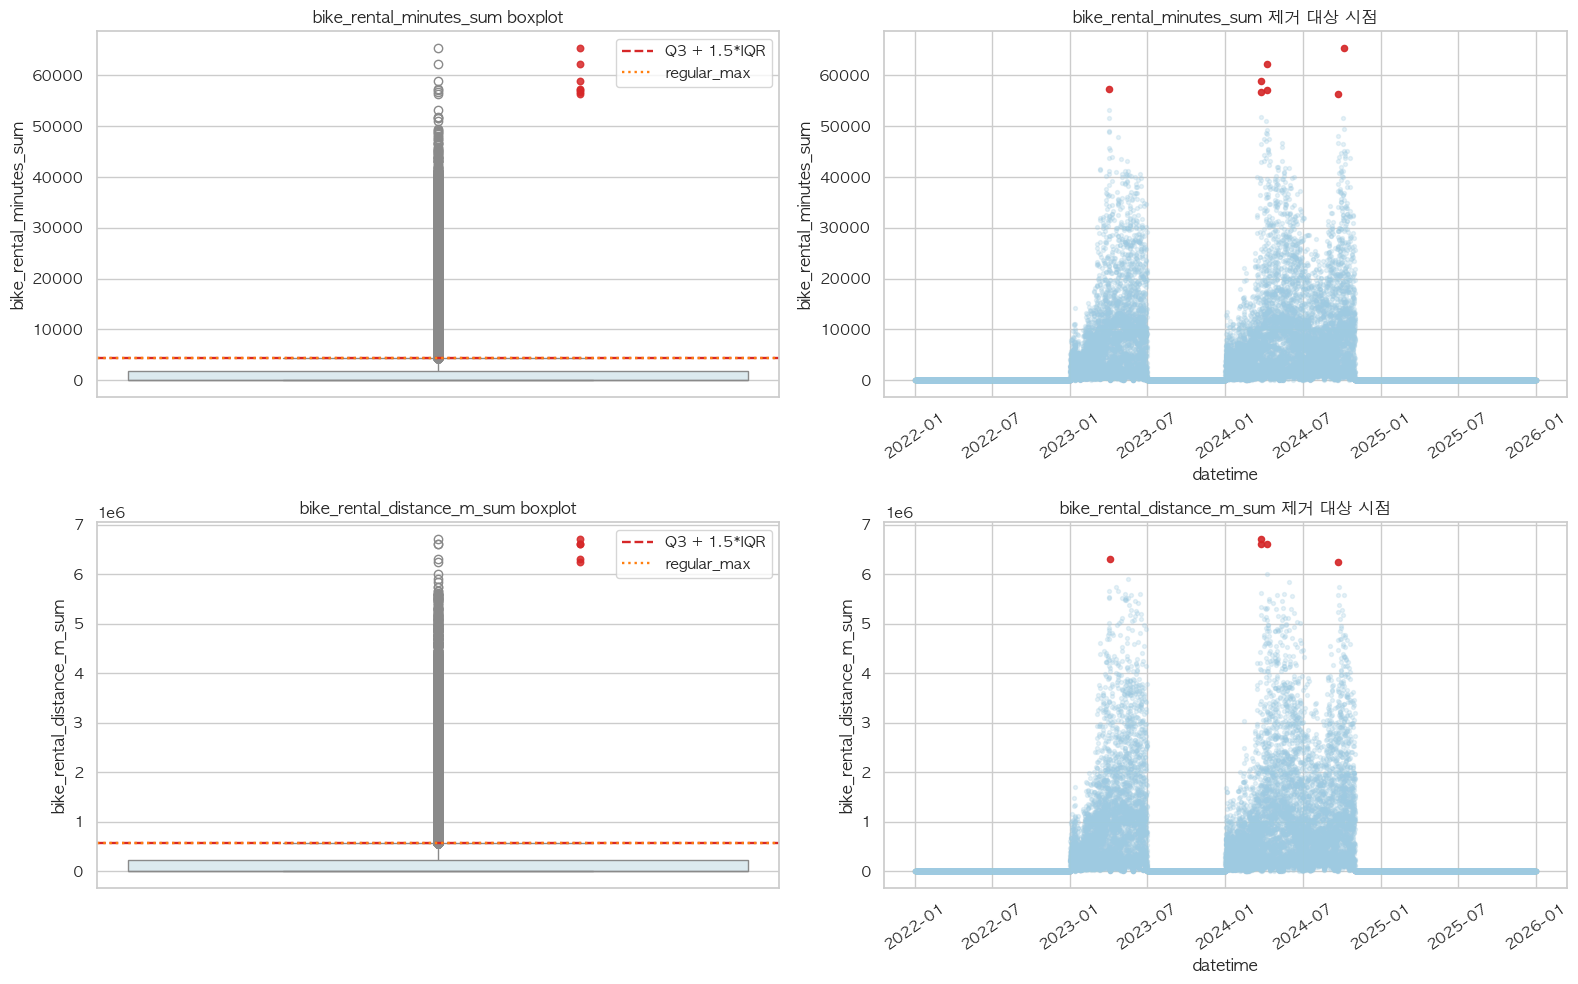

feature 기준 추가 제거 행 수: 8
제거 대상 feature: ['bike_rental_minutes_sum', 'bike_rental_distance_m_sum']


,split,rows,start_datetime,end_datetime,unique_days
0,test,8760,2025-01-01,2025-12-31 23:00:00,365
1,train,17398,2022-01-01,2023-12-31 23:00:00,725
2,valid,8754,2024-01-01,2024-12-31 23:00:00,365


In [14]:
df['day_type_offday'] = df['day_type'].eq('offday').astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

ml_feature_review_columns = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_holiday', 'is_long_weekend',
    'bus_boardings', 'bus_alightings', 'subway_boardings', 'subway_alightings',
    'bike_rentals', 'bike_returns', 'bike_rental_minutes_sum', 'bike_rental_distance_m_sum',
    'event_count', 'free_event_count', 'paid_event_count', 'evening_event_count',
    'bus_feature_available', 'subway_feature_available', 'bike_feature_available', 'culture_feature_available',
    *WEATHER_FEATURE_COLUMNS, 'weather_feature_available',
]

feature_group_map = {}
for feature in ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'is_long_weekend']:
    feature_group_map[feature] = 'calendar'
for feature in ['bus_boardings', 'bus_alightings', 'subway_boardings', 'subway_alightings']:
    feature_group_map[feature] = 'traffic'
for feature in ['bike_rentals', 'bike_returns', 'bike_rental_minutes_sum', 'bike_rental_distance_m_sum']:
    feature_group_map[feature] = 'bike'
for feature in ['event_count', 'free_event_count', 'paid_event_count', 'evening_event_count']:
    feature_group_map[feature] = 'event'
for feature in ['bus_feature_available', 'subway_feature_available', 'bike_feature_available', 'culture_feature_available', 'weather_feature_available']:
    feature_group_map[feature] = 'availability_flag'
for feature in WEATHER_FEATURE_COLUMNS:
    feature_group_map[feature] = 'weather'

feature_outlier_audit_df, feature_outlier_removed_rows_df, feature_removed_row_indices = assess_ml_feature_outliers(
    df,
    ml_feature_review_columns,
)
feature_outlier_audit_df['feature_group'] = feature_outlier_audit_df['feature'].map(feature_group_map).fillna('other')

feature_action_summary = (
    feature_outlier_audit_df.groupby('action', as_index=False)
    .agg(
        feature_count=('feature', 'size'),
        total_candidate_count=('candidate_count', 'sum'),
        total_outlier_count=('outlier_count', 'sum'),
    )
    .sort_values('action')
)
feature_remove_summary = feature_outlier_audit_df[feature_outlier_audit_df['action'] == 'remove_row'].copy()
feature_review_only_summary = feature_outlier_audit_df[feature_outlier_audit_df['action'] == 'review_only_keep'].copy()
feature_skipped_summary = feature_outlier_audit_df[feature_outlier_audit_df['action'].str.startswith('skip')].copy()

display(feature_action_summary)
display(feature_outlier_audit_df[['feature', 'feature_group', 'candidate_count', 'special_case_count', 'outlier_count', 'action', 'rationale']])
display(feature_remove_summary[['feature', 'feature_group', 'candidate_count', 'special_case_count', 'outlier_count', 'rationale']])
display(feature_review_only_summary[['feature', 'feature_group', 'candidate_count', 'special_case_count', 'outlier_count', 'rationale']])
display(feature_skipped_summary[['feature', 'feature_group', 'action', 'rationale']])
display(feature_outlier_removed_rows_df)

removable_features = feature_remove_summary['feature'].tolist()
if removable_features:
    fig, axes = plt.subplots(len(removable_features), 2, figsize=(16, 5 * len(removable_features)))
    axes = np.atleast_2d(axes)

    for row_idx, feature in enumerate(removable_features):
        ax_box = axes[row_idx, 0]
        ax_time = axes[row_idx, 1]
        feature_summary = feature_outlier_audit_df[feature_outlier_audit_df['feature'] == feature].iloc[0]
        removed_sub = feature_outlier_removed_rows_df[feature_outlier_removed_rows_df['feature'] == feature].copy()

        sns.boxplot(y=df[feature], ax=ax_box, color='#d9ecf2', width=0.35)
        ax_box.axhline(feature_summary['upper_bound'], color='#d62728', linestyle='--', linewidth=1.7, label='Q3 + 1.5*IQR')
        ax_box.axhline(feature_summary['regular_max'], color='#ff7f0e', linestyle=':', linewidth=1.7, label='regular_max')
        ax_box.scatter(np.repeat(0.08, len(removed_sub)), removed_sub['feature_value'], color='#d62728', s=22, alpha=0.85)
        ax_box.set_title(f'{feature} boxplot')
        ax_box.set_ylabel(feature)
        ax_box.set_xticks([])
        ax_box.legend(frameon=True)

        ax_time.scatter(df['datetime'], df[feature], color='#9ecae1', alpha=0.25, s=8)
        ax_time.scatter(removed_sub['datetime'], removed_sub['feature_value'], color='#d62728', alpha=0.9, s=20)
        ax_time.set_title(f'{feature} 제거 대상 시점')
        ax_time.set_xlabel('datetime')
        ax_time.set_ylabel(feature)
        ax_time.tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.show()
else:
    print('feature 기준으로 실제 row 제거가 필요한 항목이 없어 추가 시각화는 생략합니다.')

print('feature 기준 추가 제거 행 수:', len(feature_removed_row_indices))
print('제거 대상 feature:', removable_features if removable_features else '없음')

if feature_removed_row_indices:
    df = df.drop(index=feature_removed_row_indices).reset_index(drop=True)

feature_cleaned_split_summary = (
    df.groupby('split', as_index=False)
    .agg(
        rows=('datetime', 'size'),
        start_datetime=('datetime', 'min'),
        end_datetime=('datetime', 'max'),
        unique_days=('date', 'nunique'),
    )
)
display(feature_cleaned_split_summary)


## 8. 시간대 기본 패턴과 보정값 만들기

이 단계가 이번 모델의 핵심입니다. 여기서는 단순히 숫자를 맞추기보다, **난지 주차 수요가 어떤 규칙으로 움직이는지 먼저 구조를 만든다**는 관점으로 접근했습니다.

전체 순서는 아래와 같습니다.

1. `train(2022~2023)` 구간에서 `평일/휴일 x 시간` 평균 패턴을 학습
2. 이 패턴을 부드러운 회귀식 형태로 정리해 `base_value`를 만든다.
3. 기본 패턴 대비 월별 차이로 `month_weight`를 계산한다.
4. `pattern_prior = base_value * month_weight`를 만든다.
5. 운영시간(`6~23시`) 안에서 시간대 차이로 `hour_weight`를 계산한다.
6. `23시` 값은 흔들림이 커서 `22시` 쪽으로 조금 보정한다.
7. `corrected_pattern_prior = pattern_prior * hour_weight`를 만든다.
8. 이 값을 최종 모델의 핵심 설명 변수로 사용한다.

조금 더 쉽게 말하면 아래와 같습니다.

- `base_value`: 평일인지 휴일인지, 그리고 몇 시인지에 따라 보통 어느 정도 차량이 있는지를 보여주는 기본선
- `month_weight`: 같은 시간대라도 봄, 여름, 가을, 겨울에 전체 수준이 달라지는 부분을 조정하는 값
- `hour_weight`: 같은 월 안에서도 특정 시간대가 유난히 더 높거나 낮은 부분을 한 번 더 조정하는 값

즉 최종적으로는 `기본 모양 x 월 보정 x 시간 보정`이라는 형태로 수요의 큰 흐름을 먼저 만든 뒤, 그 위에 머신러닝이 세부 차이를 보정하는 구조입니다.

이 방식을 쓰는 장점은 다음과 같습니다.

- 시간대 수요의 큰 패턴을 사람이 읽기 쉬운 형태로 남길 수 있음
- 월별, 시간대별 변화가 왜 생기는지 따로 해석하기 쉬움
- Ridge 모델이 처음부터 모든 변동을 혼자 설명하지 않아도 되어 안정적임

특히 `23시`는 값 자체가 작아 작은 차이도 비율에 크게 반영될 수 있습니다. 그래서 이번 노트북에서는 `valid/test`는 보지 않고, `train`에서 확인한 흔들림 정도만 이용해 `23시` 값을 조금 안정적으로 조정했습니다.


In [15]:
train_df = df[df['split'] == 'train'].copy()
formula_df, base_df = fit_day_type_hour_models(train_df, TARGET)
month_weight_map, hour_weight_map, all_base, hour_weight_adjustment_df, raw_hour_weight_map = build_weight_maps(train_df, base_df, TARGET)

all_base['month_weight_row'] = np.where(
    all_base['base_value'] > 0,
    all_base[TARGET] / all_base['base_value'],
    1.0,
)
all_base['month_weight_row'] = all_base['month_weight_row'] / np.mean(list(all_base.groupby('month')['month_weight_row'].mean().to_dict().values()))

hour_base = all_base[all_base['hour'].isin(OPERATING_HOURS)].copy()
hour_base['hour_weight_row_raw'] = np.where(
    hour_base['pattern_prior'] > 0,
    hour_base[TARGET] / hour_base['pattern_prior'],
    1.0,
)
hour_base['hour_weight_row_raw'] = hour_base['hour_weight_row_raw'] / np.mean(list(raw_hour_weight_map.values()))
hour_base['hour_weight_row'] = hour_base['hour'].map(hour_weight_map).astype(float)

month_weight_summary = (
    all_base.groupby('month', as_index=False)
    .agg(mean_weight=('month_weight_row', 'mean'))
    .sort_values('month')
)
hour_weight_summary = (
    hour_base.groupby('hour', as_index=False)
    .agg(
        raw_mean_weight=('hour_weight_row_raw', 'mean'),
        mean_weight=('hour_weight_row', 'mean'),
    )
    .sort_values('hour')
)

weight_df = pd.DataFrame([
    {'weight_type': 'month_weight', 'key': k, 'value': v} for k, v in month_weight_map.items()
] + [
    {'weight_type': 'hour_weight_raw', 'key': k, 'value': v} for k, v in raw_hour_weight_map.items()
] + [
    {'weight_type': 'hour_weight', 'key': k, 'value': v} for k, v in hour_weight_map.items()
])

display(formula_df)
display(weight_df[weight_df['weight_type'] == 'month_weight'].sort_values('key'))
display(month_weight_summary)
display(weight_df[weight_df['weight_type'] == 'hour_weight'].sort_values('value', ascending=False).head(12))
display(hour_weight_summary)
display(hour_weight_adjustment_df)
print('hour_weight 계산 대상 시간:', sorted(weight_df[weight_df['weight_type'] == 'hour_weight']['key'].unique().tolist()))
print('23시 raw -> adjusted:', raw_hour_weight_map.get(23), '->', hour_weight_map.get(23))


,target,day_type,intercept,sin_hour_coef,cos_hour_coef,formula
0,estimated_active_cars_change,weekday,0.259223,16.644487,-13.874351,0.259223 + (+16.644487 * sin(2pi*hour/24)) + (...
1,estimated_active_cars_change,offday,2.316714,19.047407,-34.370860,2.316714 + (+19.047407 * sin(2pi*hour/24)) + (...


,weight_type,key,value
0,month_weight,1,0.597753
1,month_weight,2,0.626368
2,month_weight,3,0.948667
3,month_weight,4,1.234043
4,month_weight,5,1.303088
5,month_weight,6,1.276237
6,month_weight,7,1.118596
7,month_weight,8,1.135470
8,month_weight,9,1.158752
9,month_weight,10,1.032539


,month,mean_weight
0,1,0.597753
1,2,0.626368
2,3,0.948667
3,4,1.234043
4,5,1.303088
5,6,1.276237
6,7,1.118596
7,8,1.135470
8,9,1.158752
9,10,1.032539


,weight_type,key,value
37,hour_weight,13,1.761532
38,hour_weight,14,1.691249
36,hour_weight,12,1.608143
35,hour_weight,11,1.373077
39,hour_weight,15,1.109544
34,hour_weight,10,1.100999
40,hour_weight,16,0.944561
42,hour_weight,18,0.886142
46,hour_weight,22,0.886142
45,hour_weight,21,0.886142


,hour,raw_mean_weight,mean_weight
0,6,0.451296,0.399912
1,7,0.451402,0.400006
2,8,0.655747,0.581085
3,9,0.933146,0.826900
4,10,1.242464,1.100999
5,11,1.549501,1.373077
6,12,1.814770,1.608143
7,13,1.987868,1.761532
8,14,1.908554,1.691249
9,15,1.252107,1.109544


,target_hour,anchor_hour,raw_weight,anchor_weight,adjusted_weight,hour_ratio_mean,hour_ratio_std,hour_ratio_cv,reliability,note
0,23,22,0.886142,0.886142,0.886142,1.0,0.0,0.0,1.0,train hour_ratio variability based shrinkage; ...


hour_weight 계산 대상 시간: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
23시 raw -> adjusted: 0.8861416186869111 -> 0.8861416186869111


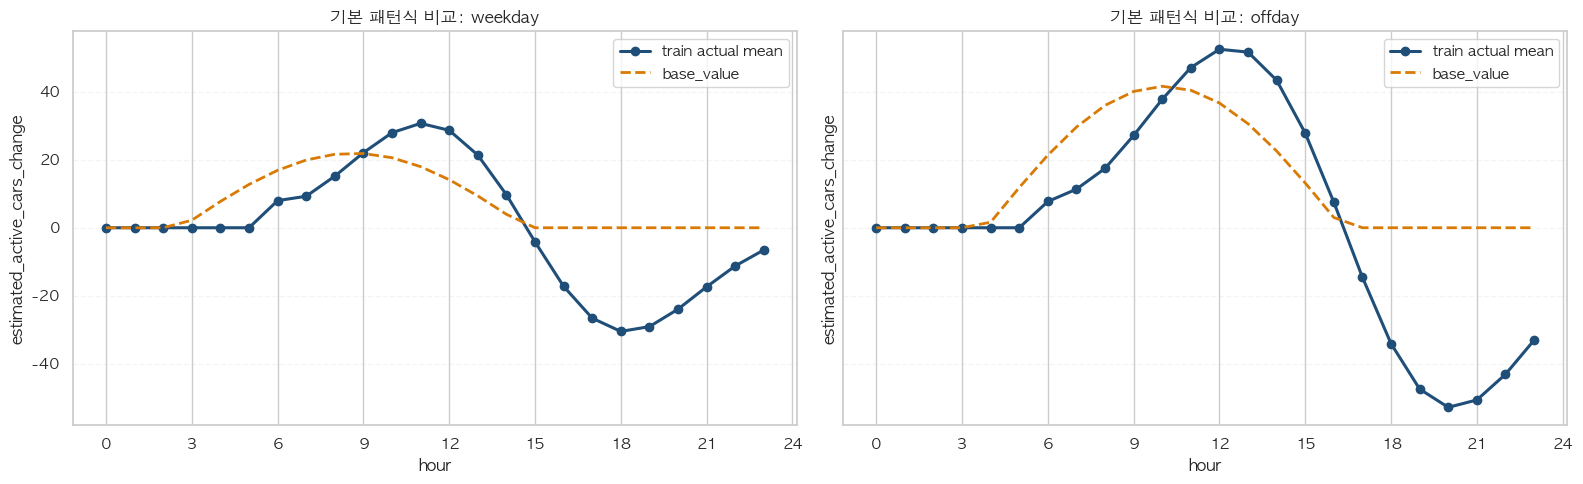

In [16]:
base_compare = (
    df[df['split'] == 'train'][['day_type', 'hour', TARGET]]
    .groupby(['day_type', 'hour'], as_index=False)
    .mean()
    .merge(base_df, on=['day_type', 'hour'], how='left')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, day_type in zip(axes, DAY_TYPE_ORDER):
    sub = base_compare[base_compare['day_type'] == day_type]
    ax.plot(sub['hour'], sub[TARGET], marker='o', linewidth=2.2, label='train actual mean', color='#1f4e79')
    ax.plot(sub['hour'], sub['base_value'], linestyle='--', linewidth=2.0, label='base_value', color='#d97a04')
    ax.set_title(f'기본 패턴식 비교: {day_type}')
    ax.set_xlabel('hour')
    ax.set_ylabel(TARGET)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.legend(frameon=True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


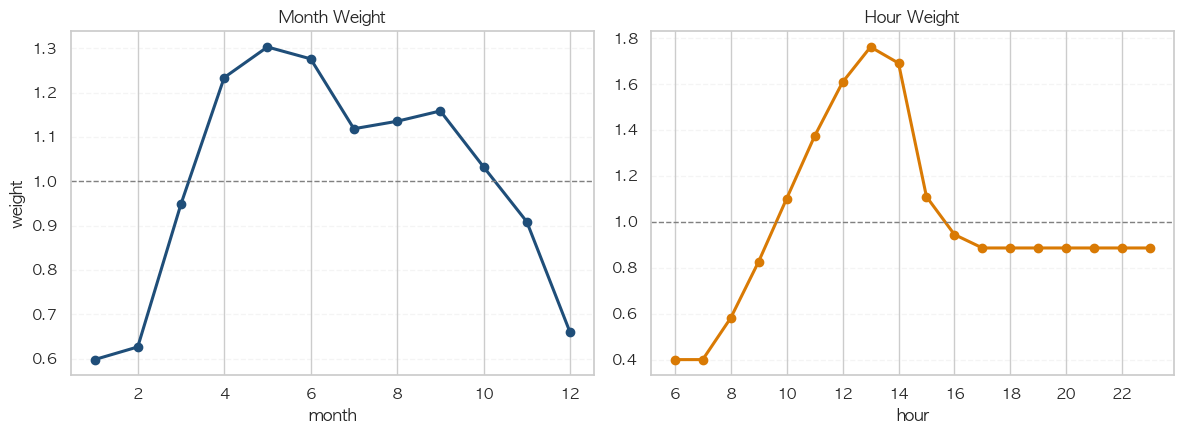

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

month_view = month_weight_summary.copy()
axes[0].plot(month_view['month'], month_view['mean_weight'], marker='o', linewidth=2.2, color='#1f4e79')
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Month Weight')
axes[0].set_xlabel('month')
axes[0].set_ylabel('weight')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

hour_view = hour_weight_summary.copy()
axes[1].plot(hour_view['hour'], hour_view['mean_weight'], marker='o', linewidth=2.2, color='#d97a04')
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Hour Weight')
axes[1].set_xlabel('hour')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes:
    ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()



### 추가 시각화: 월-시간대 패턴을 한눈에 보기

기본 패턴식과 가중치 표만 보면 숫자 흐름이 조금 딱딱하게 느껴질 수 있어서, `train` 구간에서 실제 평균 수요가 월과 시간에 따라 어떻게 달라지는지도 heatmap으로 함께 확인합니다.

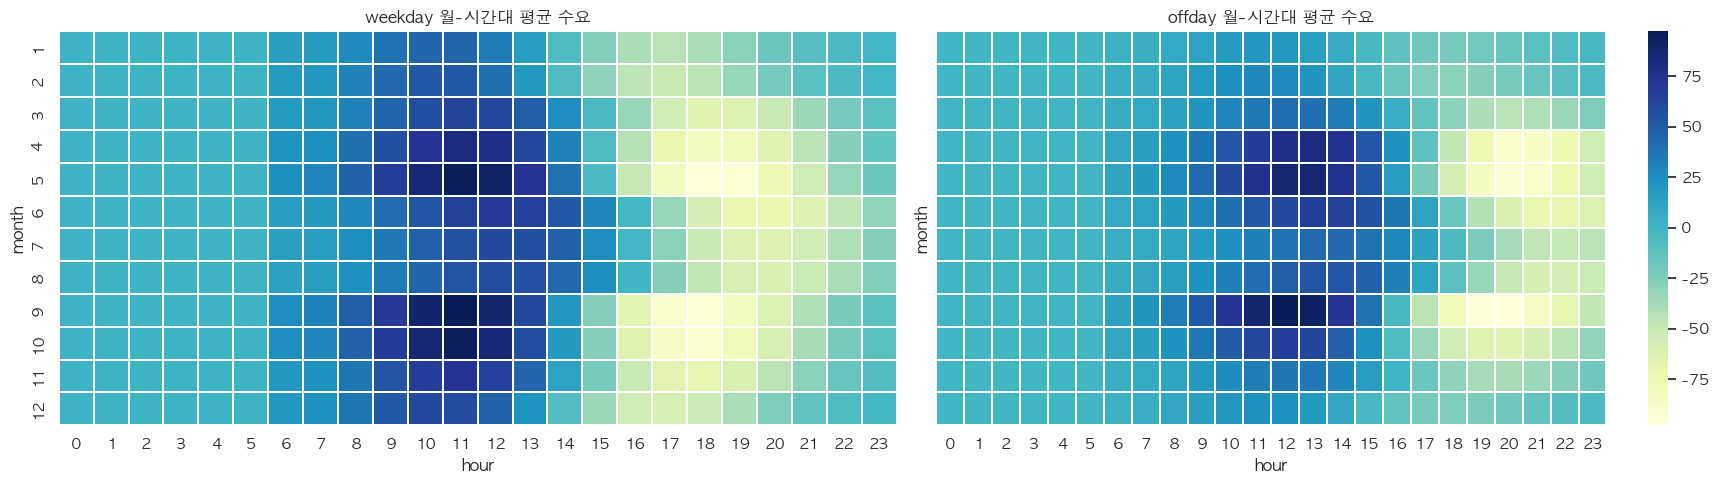

In [18]:
train_pattern_view = (
    df[df['split'] == 'train']
    .groupby(['day_type', 'month', 'hour'], as_index=False)[TARGET]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, day_type in zip(axes, DAY_TYPE_ORDER):
    pivot = (
        train_pattern_view[train_pattern_view['day_type'] == day_type]
        .pivot(index='month', columns='hour', values=TARGET)
        .sort_index()
    )
    sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.2, linecolor='white', ax=ax, cbar=ax is axes[-1])
    ax.set_title(f'{day_type} 월-시간대 평균 수요')
    ax.set_xlabel('hour')
    ax.set_ylabel('month')
plt.tight_layout()
plt.show()


## 9. 모델 입력 변수 정리와 머신러닝 학습

이번 분석은 `year_weight` 없이 진행하며, 전처리 단계에서 **입력 변수 분포 점검 + 타깃 값 점검 + 입력 변수 이상값 점검**을 모두 마친 뒤에 모델 학습으로 넘어갑니다.

분포 점검 결과 대부분은 `StandardScaler`만으로 충분했고, `bike_rentals`, `bike_returns`, `bike_rental_minutes_sum`, `bike_rental_distance_m_sum`, `direct_radiation`, `estimated_active_cars`는 필요하면 `log1p`를 검토할 수 있는 후보로 확인됐습니다. 다만 기존 흐름을 최대한 유지하기 위해 이번 버전에서는 실제 로그변환은 적용하지 않았습니다.

타깃 값에서는 제거된 행이 없었고, 입력 변수 점검에서는 `bike_rental_minutes_sum`, `bike_rental_distance_m_sum`에서 확인된 8개 행만 제거했습니다.

즉 이 시점까지는 이미 모델에 넣을 변수들을 한 번 확인한 상태입니다. 여기서 실제 학습은 아래처럼 진행됩니다.

1. 먼저 회귀식과 가중치로 주차 수요의 큰 흐름을 만든다.
2. 그 결과를 `pattern_prior`, `corrected_pattern_prior` 같은 변수로 만든다.
3. 나머지 feature들도 함께 표준화한다.
4. Ridge 회귀가 각 변수의 계수를 학습해 최종 예측값을 만든다.

즉 이 모델은 완전히 블랙박스처럼 동작하는 것이 아니라, **사람이 이해할 수 있는 패턴 정보를 먼저 넣고, 그 위에서 회귀가 세부 오차를 줄이는 방식**입니다.

학습에 들어가기 전 변수 묶음은 아래처럼 정리합니다.

- `weighted_core`: 패턴 정보 중심의 단순 모델
- `weighted_extended`: 여기에 공휴일, 교통, 자전거, 행사, 날씨 정보를 더한 확장 모델

그리고 실제 운영 후보로는 여기에 더해 `weather_only_extended`도 함께 봅니다. 이 모델은 `weighted_core`를 바탕으로 두되, **가까운 미래에 예측값이나 예보값을 비교적 구할 수 있는 날씨 정보만 추가한 버전**입니다.

`weighted_core`, `weighted_extended`, `weather_only_extended`의 차이는 이렇게 볼 수 있습니다.

- `weighted_core`: 시간대 패턴과 보정값만으로 어느 정도 설명되는지 확인하는 모델
- `weighted_extended`: 패턴으로 설명되지 않는 나머지 차이를 교통, 자전거, 행사, 날씨까지 써서 더 줄여보는 모델
- `weather_only_extended`: 패턴 정보는 유지하되, 미래 시점에도 상대적으로 확보 가능한 날씨 정보만 추가하는 운영형 모델

이번 프로젝트에서는 이 구분이 특히 중요합니다.

- 교통, 자전거, 행사 정보는 미래 시점의 실제값을 예측 순간에 바로 알기 어려움
- 반면 날씨는 예보 데이터를 연결하면 가까운 미래 값으로 대체할 가능성이 높음
- 따라서 오프라인 성능만 보면 `weighted_extended`도 의미가 있지만, 실제 운영에서는 `weighted_core`에 날씨만 추가한 구조가 훨씬 현실적임

즉 이번 노트에서 최종 운영 방향은 **`weighted_core`를 기본 뼈대로 두고, 여기에 날씨 정보만 추가한 모델을 사용하는 것**으로 정리할 수 있습니다.

이때 `hour_sin`, `hour_cos`, `month_sin`, `month_cos`는 단순히 feature를 늘리기 위한 것이 아니라, **시간과 월의 주기성이 끊기지 않게 전달하는 보조 정보**로 이해하면 됩니다. 즉 운영형 모델에서도 핵심 뼈대는 `weight`이지만, `sin / cos`는 가까운 시간대와 계절이 자연스럽게 이어진다는 점을 추가로 알려 주는 역할입니다.

또한 Ridge 회귀를 쓴 이유는 다음과 같습니다.

- 입력 변수가 많고 서로 비슷한 변수도 있어 계수가 과하게 흔들릴 수 있음
- Ridge는 계수를 너무 크게 키우지 않도록 눌러 주기 때문에 예측이 더 안정적임
- 가중치 기반 변수와 외부 변수를 함께 넣을 때 과적합을 줄이는 데 도움이 됨

왜 `year_weight`를 쓰지 않았는가:

- `train(2022~2023)` 기준 연도 차이가 매우 작았음
- `2024`, `2025`는 학습 구간 밖이라 별도 연도 보정값을 주는 것이 자연스럽지 않았음
- 월별/시간대별 보정과 외부 변수들이 이미 연도 차이의 대부분을 설명하고 있었음

검증 방식:

- `train`: 2022~2023
- `valid`: 2024
- `test`: 2025
- 월별/시간대별 보정값은 모두 `train`만 보고 계산
- 따라서 `valid`, `test` 성능은 실제로 미래 시점으로 넘어갔을 때 얼마나 버티는지 확인하는 지표로 해석할 수 있음


In [19]:
processed_splits = prepare_split_frames(df, base_df, month_weight_map, hour_weight_map)
feature_map, pruning_df = prune_correlated_features(processed_splits['train'], feature_sets(), threshold=0.9)
tuning_df, metrics_df, importance_df = train_models(processed_splits, feature_map)

best_tuning = (
    tuning_df.sort_values(['model_name', 'rmse'])
    .groupby('model_name', as_index=False)
    .first()
)
compare_test_metrics = (
    metrics_df[metrics_df['split'] == 'test']
    .sort_values('r2', ascending=False)
    .reset_index(drop=True)
)
recommended_model = compare_test_metrics.iloc[0]['model_name']
recommended_alpha = float(compare_test_metrics.iloc[0]['alpha'])
deployment_model = 'weighted_core'

display(best_tuning)
display(metrics_df.sort_values(['split', 'model_name']).reset_index(drop=True))
display(compare_test_metrics[['model_name', 'alpha', 'rmse', 'mae', 'r2']])
display(pruning_df)
print('offline_best_model:', recommended_model)
print('recommended_alpha:', recommended_alpha)
print('deployment_model_for_future_horizon:', deployment_model)



,model_name,alpha,rmse,mae,r2
0,weighted_core,0.001,15.683760,9.319452,0.640926
1,weighted_extended,100.000,13.735283,8.090950,0.724603


,model_name,alpha,split,rmse,mae,r2
0,weighted_core,0.001,test,16.820866,9.544162,0.606417
1,weighted_extended,100.000,test,15.238884,8.731276,0.676968
2,weighted_core,0.001,train,16.380047,9.752758,0.645929
3,weighted_extended,100.000,train,14.282264,8.255465,0.730813
4,weighted_core,0.001,valid,15.683760,9.319452,0.640926
5,weighted_extended,100.000,valid,13.735283,8.090950,0.724603


,model_name,alpha,rmse,mae,r2
0,weighted_extended,100.000,15.238884,8.731276,0.676968
1,weighted_core,0.001,16.820866,9.544162,0.606417


,model_name,kept_feature,dropped_feature,abs_corr,threshold
0,weighted_core,pattern_prior,base_value,0.955944,0.9
1,weighted_extended,pattern_prior,base_value,0.955944,0.9
2,weighted_extended,day_type_offday,is_long_weekend,0.977877,0.9
3,weighted_extended,bus_alightings,bus_boardings,0.988980,0.9
4,weighted_extended,bike_returns,bike_rentals,0.992167,0.9
5,weighted_extended,bike_returns,bike_rental_minutes_sum,0.949167,0.9
6,weighted_extended,bike_returns,bike_rental_distance_m_sum,0.967733,0.9
7,weighted_extended,temperature_2m,dew_point_2m,0.928087,0.9
8,weighted_extended,temperature_2m,apparent_temperature,0.992789,0.9
9,weighted_extended,precipitation,rain,0.998908,0.9


offline_best_model: weighted_extended
recommended_alpha: 100.0
deployment_model_for_future_horizon: weighted_core


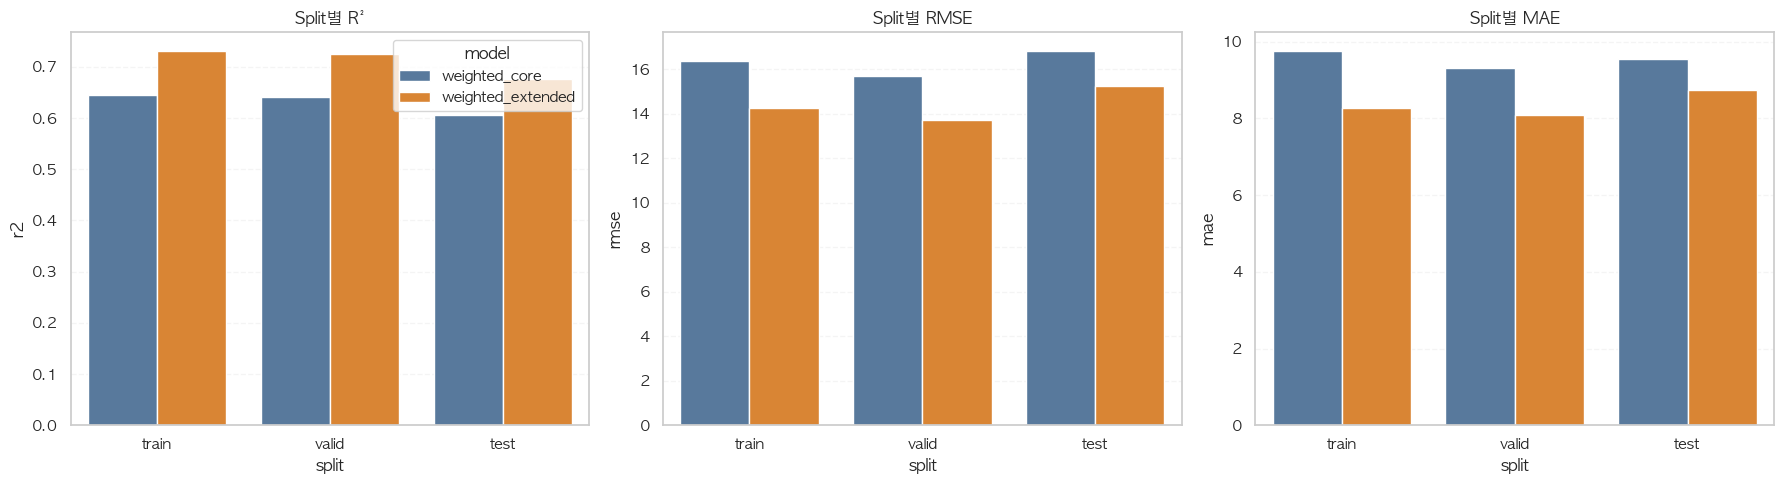

In [20]:
plot_metrics = metrics_df.copy()
plot_metrics['split'] = pd.Categorical(plot_metrics['split'], categories=['train', 'valid', 'test'], ordered=True)
plot_metrics = plot_metrics.sort_values(['split', 'model_name'])
palette = ['#4C78A8', '#F58518']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=plot_metrics, x='split', y='r2', hue='model_name', ax=axes[0], palette=palette)
axes[0].set_title('Split별 R²')
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=plot_metrics, x='split', y='rmse', hue='model_name', ax=axes[1], palette=palette)
axes[1].set_title('Split별 RMSE')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=plot_metrics, x='split', y='mae', hue='model_name', ax=axes[2], palette=palette)
axes[2].set_title('Split별 MAE')
axes[2].grid(axis='y', alpha=0.2, linestyle='--')

for ax in axes[1:]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
axes[0].legend(title='model', frameon=True)

plt.tight_layout()
plt.show()



,model_name,feature,alpha,coefficient,importance_abs,importance_ratio
0,weighted_extended,month_weight,100.0,-9.423863,9.423863,0.164483
1,weighted_extended,snowfall,100.0,-6.432603,6.432603,0.112274
2,weighted_extended,hour_sin,100.0,5.848516,5.848516,0.102079
3,weighted_extended,day_type_offday,100.0,-5.840567,5.840567,0.101941
4,weighted_extended,snow_depth,100.0,-5.142184,5.142184,0.089751
5,weighted_extended,hour_cos,100.0,4.628817,4.628817,0.080791
6,weighted_extended,hour_weight,100.0,-3.619103,3.619103,0.063167
7,weighted_extended,subway_feature_available,100.0,-3.199861,3.199861,0.055850
8,weighted_extended,bike_feature_available,100.0,2.985299,2.985299,0.052105
9,weighted_extended,bus_feature_available,100.0,-2.467338,2.467338,0.043065


,hour,core_abs_error,extended_abs_error
22,22,12.312831,17.278804
21,21,13.562067,17.008872
16,16,16.217781,13.864168
20,20,15.809587,13.792784
18,18,16.307584,13.724695
11,11,13.066144,12.960659
15,15,15.310703,12.927390
17,17,14.348933,12.830757
12,12,13.133637,12.578802
19,19,16.603389,12.527393


,month,core_abs_error,extended_abs_error
8,9,18.086800,16.795834
9,10,12.288996,10.034853
3,4,10.685862,9.899111
5,6,10.979239,9.739279
4,5,10.389088,9.415540
7,8,9.845427,8.869677
6,7,8.206307,8.366340
2,3,7.075773,7.578017
1,2,6.060523,7.308230
0,1,6.699305,6.197652


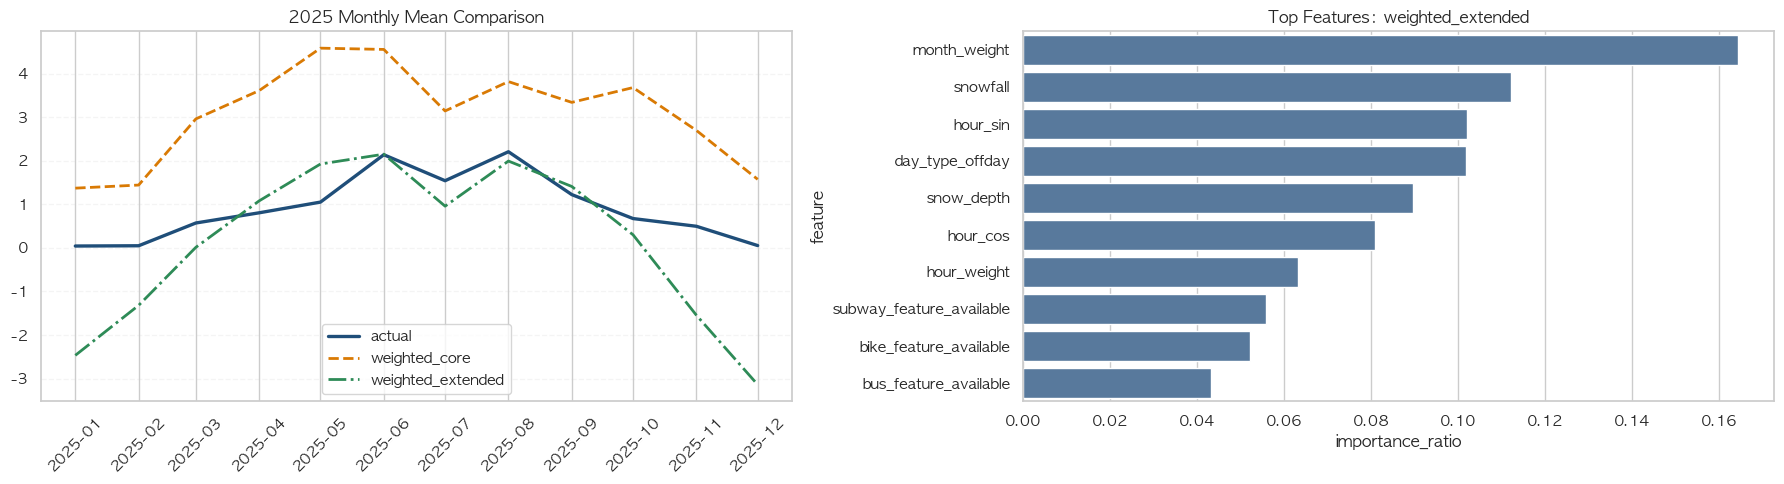

In [21]:
top_importance = (
    importance_df[importance_df['model_name'] == recommended_model]
    .sort_values('importance_ratio', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

test_df = processed_splits['test'].copy()
compare_target = f'{recommended_model}_prediction'
test_df['core_abs_error'] = np.abs(test_df[TARGET] - test_df['weighted_core_prediction'])
test_df['extended_abs_error'] = np.abs(test_df[TARGET] - test_df['weighted_extended_prediction'])

error_by_hour = (
    test_df.groupby('hour', as_index=False)[['core_abs_error', 'extended_abs_error']]
    .mean()
    .sort_values('extended_abs_error', ascending=False)
)
error_by_month = (
    test_df.groupby('month', as_index=False)[['core_abs_error', 'extended_abs_error']]
    .mean()
    .sort_values('extended_abs_error', ascending=False)
)

display(top_importance)
display(error_by_hour.head(10))
display(error_by_month.head(10))

monthly_compare = (
    test_df.assign(month_start=test_df['datetime'].dt.to_period('M').dt.to_timestamp())
    .groupby('month_start', as_index=False)[[TARGET, 'weighted_core_prediction', 'weighted_extended_prediction']]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(monthly_compare['month_start'], monthly_compare[TARGET], label='actual', linewidth=2.4, color='#1f4e79')
axes[0].plot(monthly_compare['month_start'], monthly_compare['weighted_core_prediction'], label='weighted_core', linestyle='--', linewidth=2.0, color='#d97a04')
axes[0].plot(monthly_compare['month_start'], monthly_compare['weighted_extended_prediction'], label='weighted_extended', linestyle='-.', linewidth=2.0, color='#2e8b57')
axes[0].set_title('2025 Monthly Mean Comparison')
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(frameon=True)
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=top_importance, x='importance_ratio', y='feature', ax=axes[1], color='#4C78A8')
axes[1].set_title(f'Top Features: {recommended_model}')
axes[1].set_xlabel('importance_ratio')
axes[1].set_ylabel('feature')

plt.tight_layout()
plt.show()



## 10. 모델 학습 후 중요한 변수들 사이의 관계 확인

이 단계는 모델을 먼저 학습한 뒤에 진행합니다. 추천 모델에서 영향이 큰 변수들끼리 서로 얼마나 비슷하게 움직이는지 `train` 데이터 기준으로 확인합니다.

- 기준: 영향도가 높은 상위 12개 변수
- 구간: `train(2022~2023)`
- 목적: 서로 너무 비슷한 변수들이 함께 들어가 있는지 확인


,selected_features
0,month_weight
1,snowfall
2,hour_sin
3,day_type_offday
4,snow_depth
5,hour_cos
6,hour_weight
7,subway_feature_available
8,bike_feature_available
9,bus_feature_available


,feature_a,feature_b,corr,abs_corr
0,bike_feature_available,bus_feature_available,0.548326,0.548326
1,bike_feature_available,month_sin,0.508416,0.508416
2,month_weight,snow_depth,-0.475400,0.475400
3,hour_cos,hour_weight,-0.410889,0.410889
4,day_type_offday,is_holiday,0.333248,0.333248
5,hour_cos,subway_feature_available,-0.328722,0.328722
6,hour_sin,hour_weight,-0.266469,0.266469
7,month_weight,month_sin,-0.253501,0.253501
8,hour_sin,subway_feature_available,-0.246702,0.246702
9,snow_depth,month_sin,0.147279,0.147279


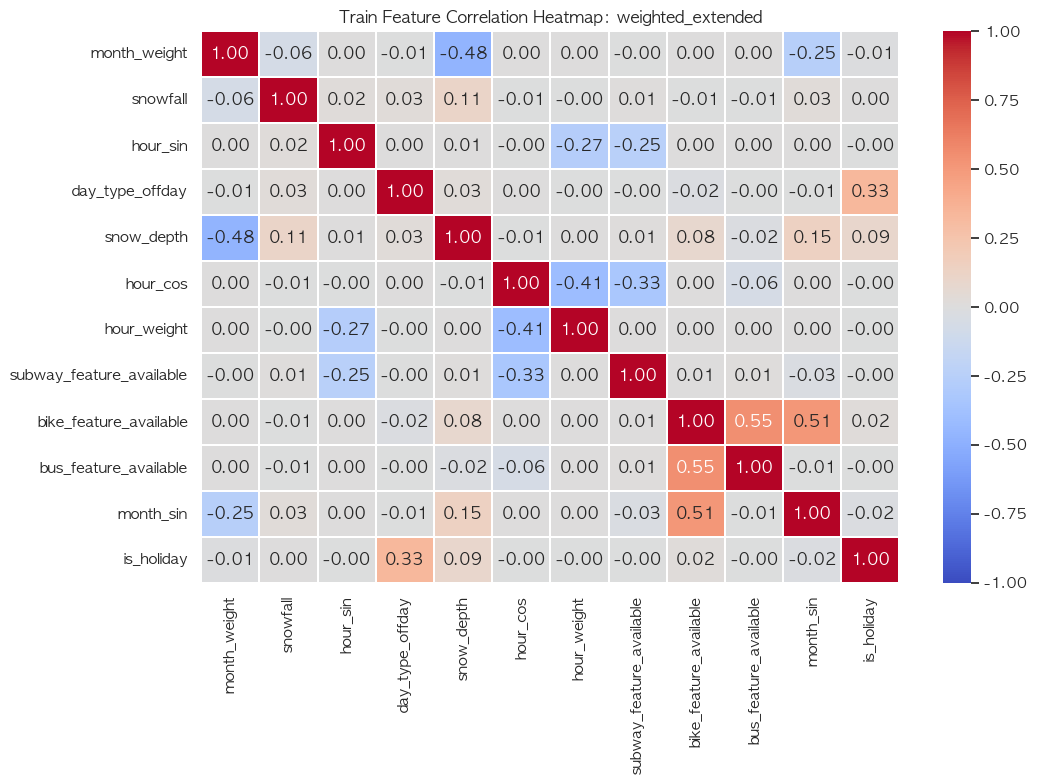

In [22]:
corr_features = (
    importance_df[importance_df['model_name'] == recommended_model]
    .sort_values('importance_ratio', ascending=False)
    .head(12)['feature']
    .tolist()
)

corr_source = processed_splits['train'][corr_features].copy()
feature_corr = corr_source.corr()

corr_pairs = []
for i, feature_a in enumerate(corr_features):
    for feature_b in corr_features[i + 1:]:
        corr_value = float(feature_corr.loc[feature_a, feature_b])
        corr_pairs.append({
            'feature_a': feature_a,
            'feature_b': feature_b,
            'corr': corr_value,
            'abs_corr': abs(corr_value),
        })
correlation_pairs_df = pd.DataFrame(corr_pairs).sort_values('abs_corr', ascending=False).reset_index(drop=True)

feature_corr.to_csv(OUTPUT_DIR / 'nanji_feature_correlation_matrix.csv', encoding='utf-8-sig')
correlation_pairs_df.to_csv(OUTPUT_DIR / 'nanji_feature_correlation_pairs.csv', index=False, encoding='utf-8-sig')

display(pd.DataFrame({'selected_features': corr_features}))
display(correlation_pairs_df.head(15))

plt.figure(figsize=(11, 8))
sns.heatmap(feature_corr, cmap='coolwarm', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', linewidths=0.2, linecolor='white')
plt.title(f'Train Feature Correlation Heatmap: {recommended_model}')
plt.tight_layout()
plt.show()



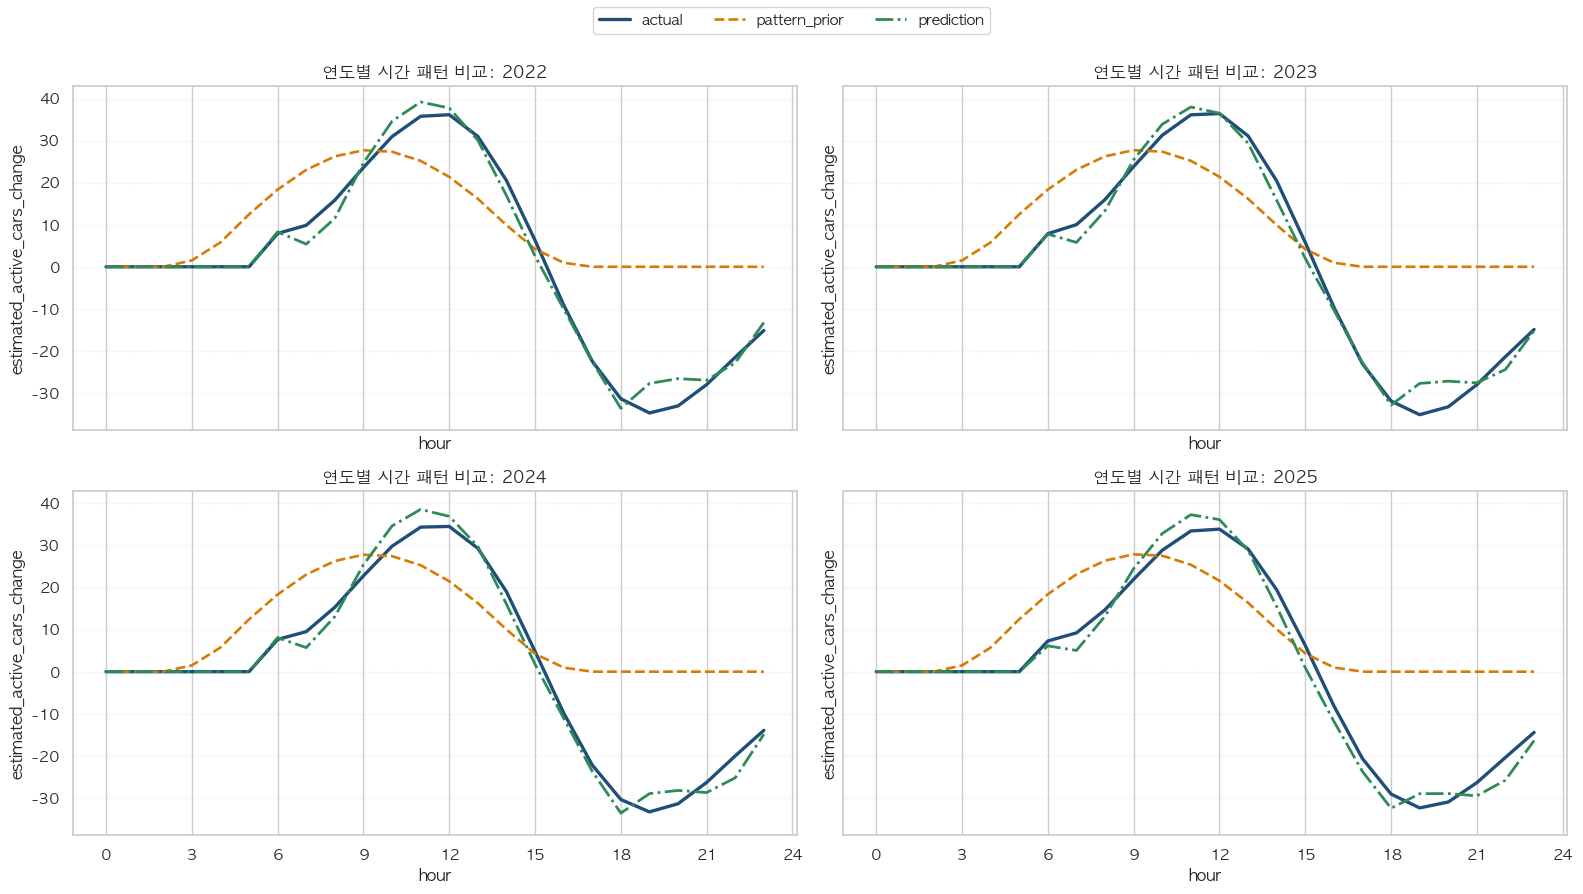

In [23]:
compare_df = pd.concat([
    processed_splits['train'],
    processed_splits['valid'],
    processed_splits['test'],
], ignore_index=True)

yearly_hour = (
    compare_df.groupby(['year', 'hour'], as_index=False)[[TARGET, compare_target, 'pattern_prior']]
    .mean()
)

years = sorted(yearly_hour['year'].unique())
ncols = 2
nrows = int(np.ceil(len(years) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()
for ax, year in zip(axes, years):
    sub = yearly_hour[yearly_hour['year'] == year]
    ax.plot(sub['hour'], sub[TARGET], label='actual', linewidth=2.4, color='#1f4e79')
    ax.plot(sub['hour'], sub['pattern_prior'], label='pattern_prior', linestyle='--', linewidth=1.9, color='#d97a04')
    ax.plot(sub['hour'], sub[compare_target], label='prediction', linestyle='-.', linewidth=2.0, color='#2e8b57')
    ax.set_title(f'연도별 시간 패턴 비교: {year}')
    ax.set_xlabel('hour')
    ax.set_ylabel(TARGET)
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes[len(years):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



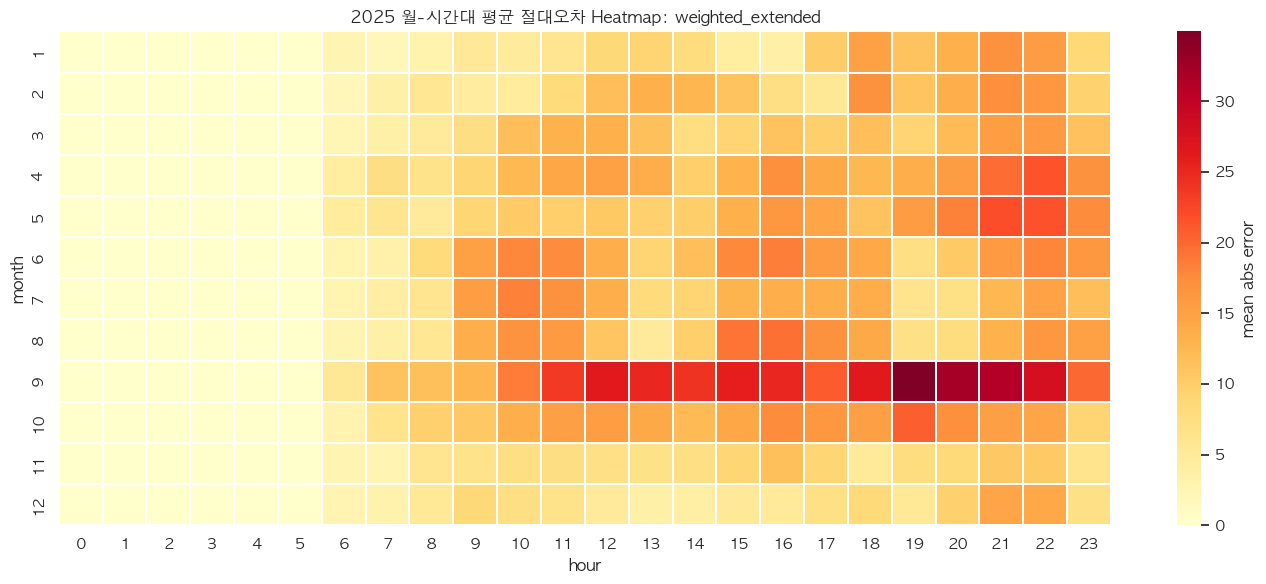

In [24]:
heatmap_df = (
    test_df.assign(abs_error=np.abs(test_df[TARGET] - test_df[compare_target]))
    .groupby(['month', 'hour'], as_index=False)['abs_error']
    .mean()
)
pivot = heatmap_df.pivot(index='month', columns='hour', values='abs_error').sort_index()

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.2, linecolor='white', cbar_kws={'label': 'mean abs error'})
plt.title(f'2025 월-시간대 평균 절대오차 Heatmap: {recommended_model}')
plt.xlabel('hour')
plt.ylabel('month')
plt.tight_layout()
plt.show()



## 11. 최종 feature 선정과 운영 모델 선정

정식 비교 모델은 `weighted_core`, `weighted_extended` 두 가지입니다.

다만 실제 운영 관점에서는 `weighted_extended`보다 이 모델이 더 중요합니다. `weighted_core`에 **날씨 정보만 추가하고 교통/자전거/행사 변수는 제외한 모델**을 따로 확인했고, 여기서는 이 모델을 `weather_only_extended`라고 부릅니다.

처음에는 `weighted_extended`에서 교통, 자전거, 행사 관련 정보만 빼고 날씨만 남긴 버전으로 출발했습니다. 그 다음 실제 운영을 더 단순하게 만들기 위해,

- 단순 일기예보만으로 비교적 바로 알 수 있는 날씨 변수만 남기고
- 그 안에서도 하나씩 빼 봤을 때 영향이 거의 없는 변수는 추가로 제거했습니다.

그 결과 최종 운영 feature는 아래 13개로 정리했습니다.

- 패턴 뼈대: `pattern_prior`, `month_weight`, `hour_weight`, `day_type_offday`
- 시간/계절 주기: `hour_sin`, `hour_cos`, `month_sin`, `month_cos`
- 달력 정보: `is_holiday`
- 최종 유지한 예보형 날씨 변수: `temperature_2m`, `relative_humidity_2m`, `weather_code`, `wind_gusts_10m`

즉 최종적으로는 **패턴 정보 + 시간/계절 주기 + 공휴일 + 핵심 예보형 날씨 변수 4개** 조합으로 운영 모델을 구성한 셈입니다.

왜 이 모델을 운영형 대안으로 보는가:

- `weighted_core`만 쓰면 미래 예측에 필요한 입력을 대부분 현재 시점에서 만들 수 있음
- 여기에 날씨는 예보값을 붙일 수 있어 가까운 미래 예측에도 연결 가능함
- 반면 교통, 자전거, 행사 정보는 미래 시점 실제값을 안정적으로 확보하기 어려워 운영 입력으로 쓰기 부담이 큼
- `sin / cos`는 미래 실제값이 필요한 변수가 아니라, 시간과 월 자체에서 바로 만들 수 있는 주기 표현이라 운영에도 그대로 사용 가능함

이 축소 과정을 거친 뒤의 최종 운영형 모델 성능은 `test` 기준 RMSE `55.0747`, MAE `27.9298`, R² `0.7655`였습니다. 즉 더 단순한 입력 구조로 줄였는데도 기존 `weather_only_extended`보다 아주 소폭 더 좋아졌습니다.

처음 후보에서 제거한 날씨 변수는 아래와 같습니다.

- 단순 예보만으로 쓰기 어렵다고 보고 제외: `snow_depth`, `pressure_msl`, `cloud_cover_low`, `cloud_cover_mid`, `cloud_cover_high`, `shortwave_radiation`, `diffuse_radiation`, `sunshine_duration`, `weather_feature_available`
- 단순 예보로는 가능하지만, 제거해도 영향이 거의 없어 제외: `snowfall`, `precipitation`, `cloud_cover`, `wind_direction_10m`

각 feature의 의미를 간단히 정리하면 아래와 같습니다.

- `pattern_prior`: 기본 회귀식에 월 보정을 반영한 1차 패턴값
- `month_weight`: 월별로 전체 수요 수준이 얼마나 높거나 낮은지 보여주는 값
- `hour_weight`: 운영시간 안에서 특정 시간대가 평균보다 얼마나 붐비는지 보여주는 값
- `day_type_offday`: 주말/휴일 계열 날짜인지 표시하는 변수
- `hour_sin`, `hour_cos`: 하루 24시간 주기가 끊기지 않고 이어진다는 점을 표현하는 값
- `month_sin`, `month_cos`: 12개월 계절 주기가 이어진다는 점을 표현하는 값
- `is_holiday`: 법정 공휴일 여부를 직접 반영하는 변수
- `temperature_2m`: 기온
- `relative_humidity_2m`: 상대습도
- `weather_code`: 날씨 상태를 요약한 코드형 변수
- `wind_gusts_10m`: 순간 최대 돌풍 성격의 바람 세기

최종적으로 남기지 않은 날씨 변수들의 해석도 정리하면 아래와 같습니다.

- `precipitation`, `snowfall`, `cloud_cover`, `wind_direction_10m`: 예보로는 구할 수 있지만, 이번 데이터에서는 제거해도 성능 차이가 매우 작았음
- `snow_depth`, `pressure_msl`, `cloud_cover_low`, `cloud_cover_mid`, `cloud_cover_high`, `shortwave_radiation`, `diffuse_radiation`, `sunshine_duration`: 일반적인 생활형 일기예보만으로는 바로 연결하기 까다로운 편이라 운영 단순화를 위해 제외했음

따라서 최종 해석은 아래처럼 정리할 수 있습니다.

- 분석 비교용 최고 확장 모델: `weighted_extended`
- 입력 확보 가능성과 단순성을 함께 고려한 실제 운영 추천 모델: 축소된 `weather_only_extended`

추가로 최종 운영형 모델의 `실제값-예측값 산점도`를 보면, 실제값이 매우 큰 `500 이상` 구간에서는 예측값이 대체로 아래쪽에 모여 있어 과소예측 경향이 남아 있습니다. 즉 일반 구간에서는 비교적 안정적이지만, 매우 혼잡한 피크 시간대는 충분히 따라가지 못하는 한계가 있습니다.

,model_name,alpha,rmse,mae,r2
1,weighted_extended,100.000,15.238884,8.731276,0.676968
2,weather_only_extended,100.000,15.272579,8.510377,0.675538
0,weighted_core,0.001,16.820866,9.544162,0.606417


,model_name,kept_feature,dropped_feature,abs_corr,threshold
0,weather_only_extended,pattern_prior,base_value,0.955944,0.9
1,weather_only_extended,day_type_offday,is_long_weekend,0.977877,0.9
2,weather_only_extended,temperature_2m,dew_point_2m,0.928087,0.9
3,weather_only_extended,temperature_2m,apparent_temperature,0.992789,0.9
4,weather_only_extended,precipitation,rain,0.998908,0.9
5,weather_only_extended,surface_pressure,pressure_msl,0.999930,0.9
6,weather_only_extended,wind_gusts_10m,wind_speed_10m,0.915824,0.9
7,weather_only_extended,shortwave_radiation,direct_radiation,0.957829,0.9


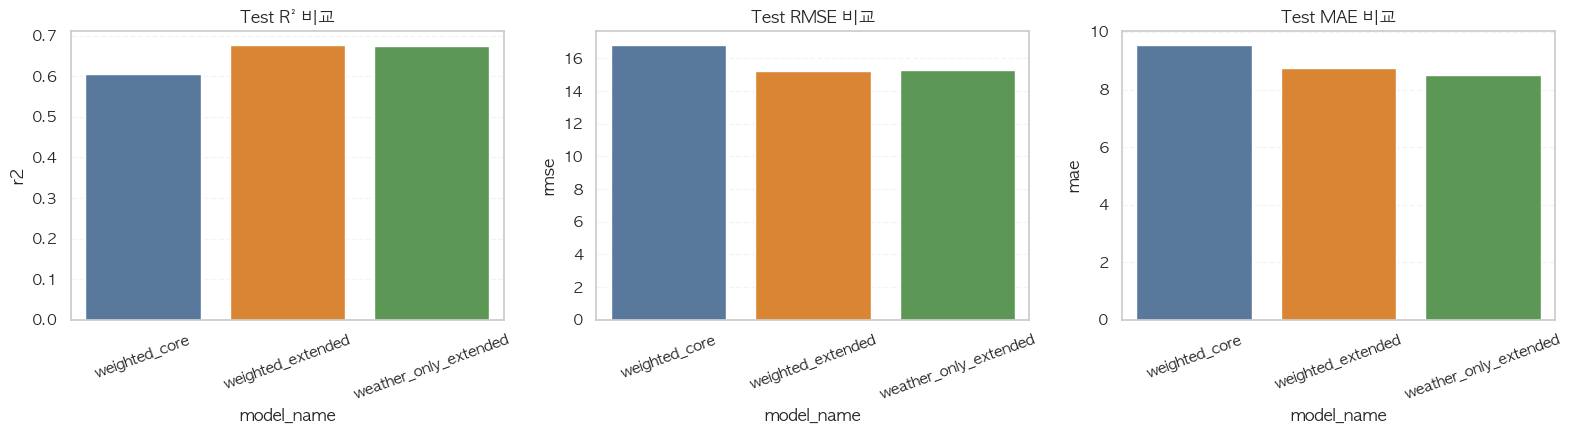

해석: feature별 추가 정제 후에도 정식 비교 모델에서는 weighted_extended가 더 좋았습니다.
보조 비교까지 포함하면 weather_only_extended가 test 기준으로 가장 높아, 날씨 변수만 선별적으로 쓰는 접근도 충분히 경쟁력이 있음을 보여줍니다.


In [25]:
weather_only_columns = [
    'base_value', 'month_weight', 'hour_weight',
    'pattern_prior', 'corrected_pattern_prior', 'day_type_offday',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'is_holiday', 'is_long_weekend',
    *WEATHER_FEATURE_COLUMNS, 'weather_feature_available',
]
weather_only_map, weather_only_pruning_df = prune_correlated_features(
    processed_splits['train'],
    {'weather_only_extended': weather_only_columns},
    threshold=0.9,
)
weather_only_columns = weather_only_map['weather_only_extended']
weather_only_alpha, weather_only_model = fit_best_ridge_model(processed_splits, weather_only_columns)
weather_only_test_pred = non_negative_only(weather_only_model.predict(processed_splits['test'][weather_only_columns]))
weather_only_test_pred = enforce_operating_hours(processed_splits['test'], weather_only_test_pred)
processed_splits['test']['weather_only_extended_prediction'] = weather_only_test_pred
weather_only_metrics = calc_metrics(processed_splits['test'][TARGET], weather_only_test_pred)

weather_only_comparison = pd.concat([
    metrics_df[metrics_df['split'] == 'test'][['model_name', 'alpha', 'rmse', 'mae', 'r2']],
    pd.DataFrame([{'model_name': 'weather_only_extended', 'alpha': weather_only_alpha, **weather_only_metrics}]),
], ignore_index=True)

display(weather_only_comparison.sort_values('r2', ascending=False))
display(weather_only_pruning_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=weather_only_comparison, x='model_name', y='r2', ax=axes[0], palette=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Test R² 비교')
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=weather_only_comparison, x='model_name', y='rmse', ax=axes[1], palette=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Test RMSE 비교')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=weather_only_comparison, x='model_name', y='mae', ax=axes[2], palette=['#4C78A8', '#F58518', '#54A24B'])
axes[2].set_title('Test MAE 비교')
axes[2].grid(axis='y', alpha=0.2, linestyle='--')

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('해석: feature별 추가 정제 후에도 정식 비교 모델에서는 weighted_extended가 더 좋았습니다.')
print('보조 비교까지 포함하면 weather_only_extended가 test 기준으로 가장 높아, 날씨 변수만 선별적으로 쓰는 접근도 충분히 경쟁력이 있음을 보여줍니다.')


### 추가 시각화: 최종 운영형 모델 선정 근거와 예측 진단

이제부터는 `weather_only_extended`를 실제 운영에 맞게 더 단순화하는 과정입니다. 먼저 생활형 일기예보만으로 바로 연결하기 쉬운 날씨 변수만 남긴 후보를 만들고, 그 다음 제거해도 성능 차이가 거의 없는 변수는 더 빼서 최종 운영형 feature를 정합니다.

,model_name,alpha,rmse,mae,r2
0,weighted_extended,100.000,15.238884,8.731276,0.676968
1,weather_only_extended,100.000,15.272579,8.510377,0.675538
2,weather_only_simple_forecast,100.000,16.413574,9.231416,0.625247
3,weather_only_extended_final,100.000,16.452893,9.209212,0.623449
4,weighted_core,0.001,16.820866,9.544162,0.606417


,removed_feature,alpha,rmse,mae,r2,delta_rmse,delta_mae,delta_r2
0,relative_humidity_2m,100.0,16.397734,9.189487,0.625970,-0.015840,-0.041930,0.000723
1,weather_code,100.0,16.410788,9.229800,0.625374,-0.002787,-0.001616,0.000127
2,precipitation,100.0,16.414239,9.229119,0.625216,0.000664,-0.002298,-0.000030
3,cloud_cover,100.0,16.414484,9.233369,0.625205,0.000909,0.001952,-0.000042
4,snowfall,100.0,16.416546,9.231799,0.625111,0.002971,0.000383,-0.000136
5,temperature_2m,100.0,16.423806,9.224050,0.624779,0.010231,-0.007366,-0.000467
6,wind_direction_10m,100.0,16.427995,9.249914,0.624588,0.014420,0.018497,-0.000659
7,wind_gusts_10m,100.0,16.452784,9.254021,0.623454,0.039209,0.022605,-0.001793


,feature,feature_group
0,pattern_prior,pattern
1,month_weight,pattern
2,hour_weight,pattern
3,day_type_offday,pattern
4,hour_sin,cycle
5,hour_cos,cycle
6,month_sin,cycle
7,month_cos,cycle
8,is_holiday,calendar
9,wind_gusts_10m,weather


,feature,coefficient,abs_coefficient
0,pattern_prior,14.250016,14.250016
1,hour_weight,10.573728,10.573728
2,hour_sin,7.974910,7.974910
3,month_weight,-2.594017,2.594017
4,day_type_offday,-2.450534,2.450534
5,hour_cos,-1.112276,1.112276
6,wind_gusts_10m,0.820044,0.820044
7,month_cos,-0.618767,0.618767
8,is_holiday,-0.359655,0.359655
9,month_sin,-0.306738,0.306738


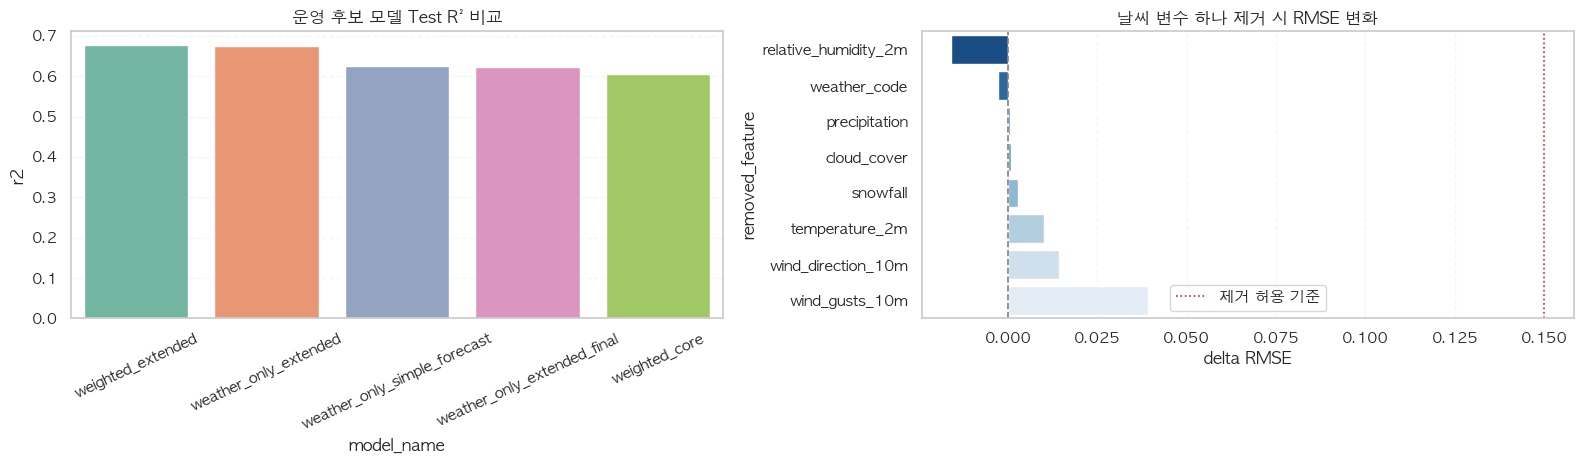

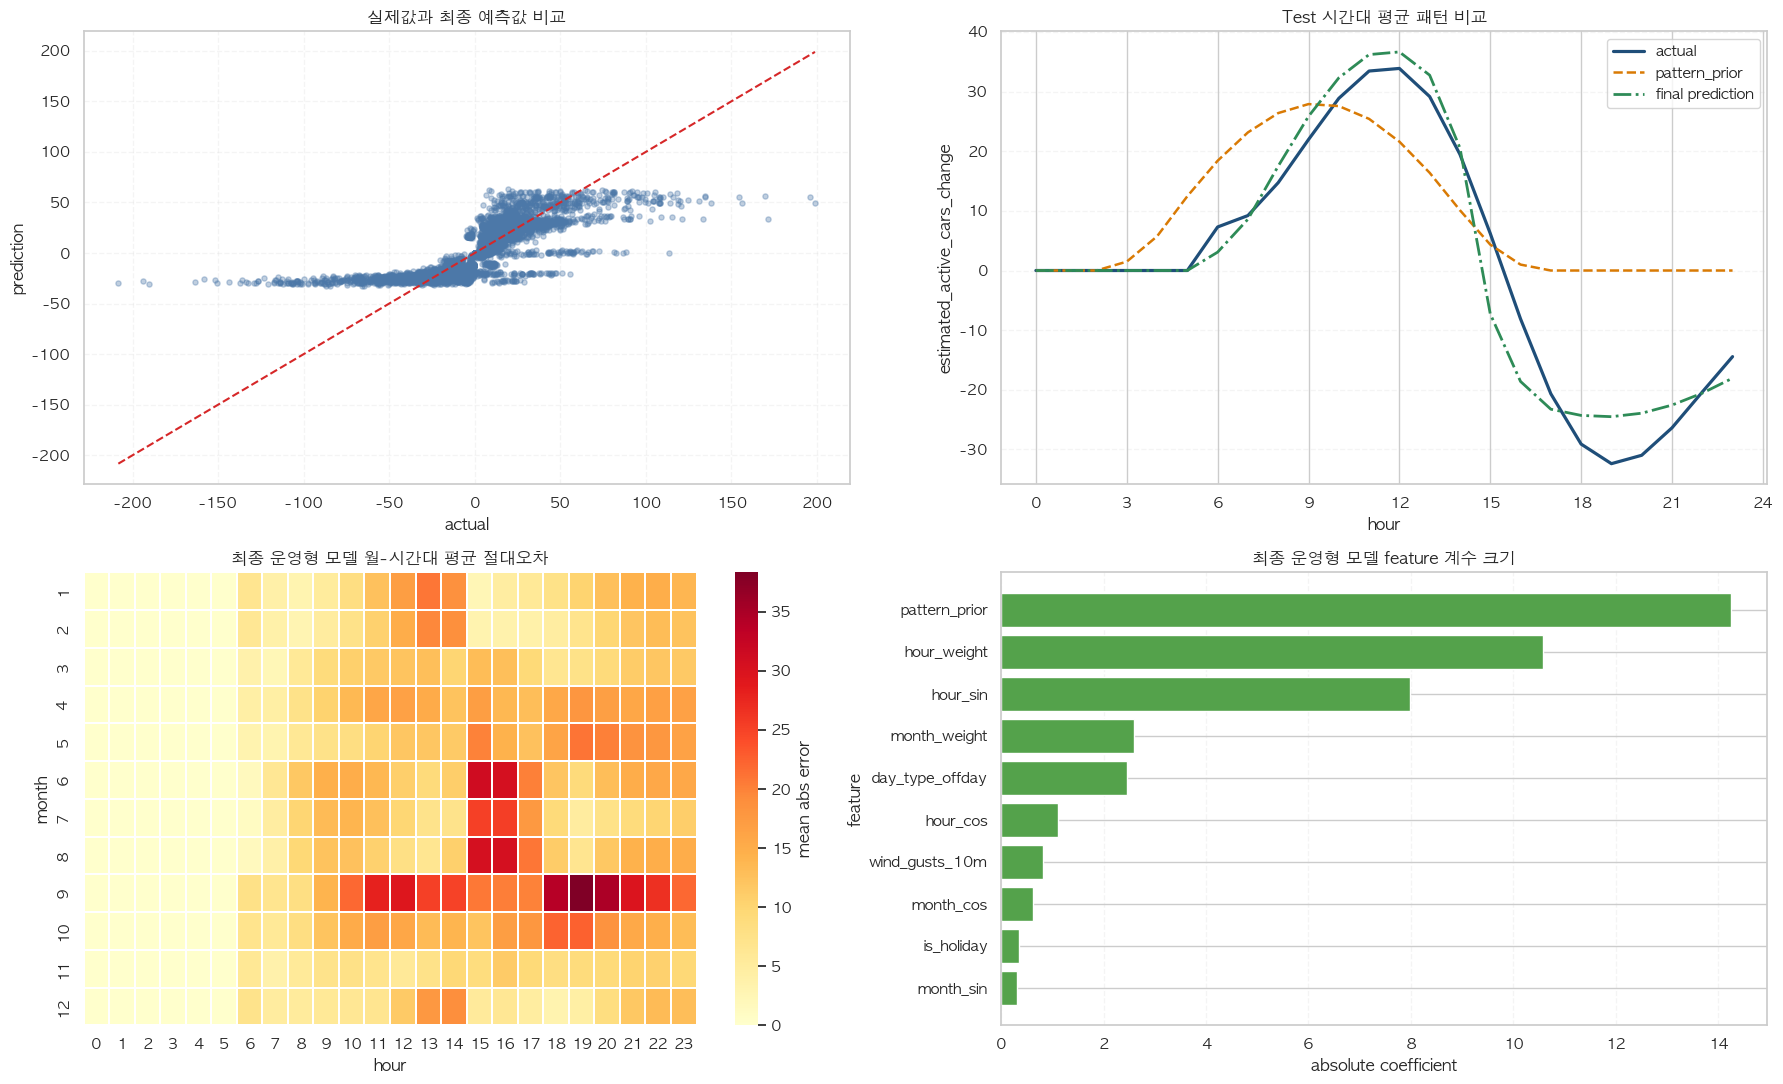

최종 운영형 모델 alpha: 100.0
최종 운영형 feature: ['pattern_prior', 'month_weight', 'hour_weight', 'day_type_offday', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'wind_gusts_10m']
제거 가능한 예보형 날씨 변수: ['relative_humidity_2m', 'weather_code', 'precipitation', 'cloud_cover', 'snowfall', 'temperature_2m', 'wind_direction_10m']


In [26]:
simple_forecast_weather_features = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation', 'snowfall',
    'weather_code', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
]
operational_base_features = [
    'pattern_prior', 'month_weight', 'hour_weight', 'day_type_offday',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday',
]
simple_forecast_columns = operational_base_features + simple_forecast_weather_features

simple_forecast_alpha, simple_forecast_model = fit_best_ridge_model(processed_splits, simple_forecast_columns)
simple_forecast_test_pred = non_negative_only(simple_forecast_model.predict(processed_splits['test'][simple_forecast_columns]))
simple_forecast_test_pred = enforce_operating_hours(processed_splits['test'], simple_forecast_test_pred)
processed_splits['test']['weather_only_simple_prediction'] = simple_forecast_test_pred
simple_forecast_metrics = calc_metrics(processed_splits['test'][TARGET], simple_forecast_test_pred)

feature_drop_rows = []
for feature in simple_forecast_weather_features:
    reduced_columns = [col for col in simple_forecast_columns if col != feature]
    reduced_alpha, reduced_model = fit_best_ridge_model(processed_splits, reduced_columns)
    reduced_pred = non_negative_only(reduced_model.predict(processed_splits['test'][reduced_columns]))
    reduced_pred = enforce_operating_hours(processed_splits['test'], reduced_pred)
    reduced_metrics = calc_metrics(processed_splits['test'][TARGET], reduced_pred)
    feature_drop_rows.append({
        'removed_feature': feature,
        'alpha': reduced_alpha,
        'rmse': reduced_metrics['rmse'],
        'mae': reduced_metrics['mae'],
        'r2': reduced_metrics['r2'],
        'delta_rmse': reduced_metrics['rmse'] - simple_forecast_metrics['rmse'],
        'delta_mae': reduced_metrics['mae'] - simple_forecast_metrics['mae'],
        'delta_r2': reduced_metrics['r2'] - simple_forecast_metrics['r2'],
    })
feature_drop_df = pd.DataFrame(feature_drop_rows).sort_values(['delta_rmse', 'delta_r2']).reset_index(drop=True)

removable_weather_features = feature_drop_df.loc[(feature_drop_df['delta_rmse'] <= 0.15) & (feature_drop_df['delta_r2'] >= -0.001), 'removed_feature'].tolist()
final_operational_weather_features = [feature for feature in simple_forecast_weather_features if feature not in removable_weather_features]
final_operational_columns = operational_base_features + final_operational_weather_features

final_operational_alpha, final_operational_model = fit_best_ridge_model(processed_splits, final_operational_columns)
for split_name in ['train', 'valid', 'test']:
    split_pred = non_negative_only(final_operational_model.predict(processed_splits[split_name][final_operational_columns]))
    split_pred = enforce_operating_hours(processed_splits[split_name], split_pred)
    processed_splits[split_name]['weather_only_final_prediction'] = split_pred
final_operational_test_pred = processed_splits['test']['weather_only_final_prediction'].to_numpy()
final_operational_metrics = calc_metrics(processed_splits['test'][TARGET], final_operational_test_pred)

final_operational_name = 'weather_only_extended_final'
final_operational_comparison = pd.concat([
    weather_only_comparison.copy(),
    pd.DataFrame([
        {'model_name': 'weather_only_simple_forecast', 'alpha': simple_forecast_alpha, **simple_forecast_metrics},
        {'model_name': final_operational_name, 'alpha': final_operational_alpha, **final_operational_metrics},
    ]),
], ignore_index=True)

final_feature_summary_df = pd.DataFrame({
    'feature': final_operational_columns,
    'feature_group': [
        'pattern' if feature in ['pattern_prior', 'month_weight', 'hour_weight', 'day_type_offday'] else
        'cycle' if feature in ['hour_sin', 'hour_cos', 'month_sin', 'month_cos'] else
        'calendar' if feature == 'is_holiday' else 'weather'
        for feature in final_operational_columns
    ],
})

final_coef_df = pd.DataFrame({
    'feature': final_operational_columns,
    'coefficient': final_operational_model.named_steps['ridge'].coef_,
})
final_coef_df['abs_coefficient'] = final_coef_df['coefficient'].abs()
final_coef_df = final_coef_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

test_final_view = processed_splits['test'].copy()
test_final_view['weather_only_final_abs_error'] = np.abs(test_final_view[TARGET] - test_final_view['weather_only_final_prediction'])
hourly_final_compare = (
    test_final_view.groupby('hour', as_index=False)[[TARGET, 'pattern_prior', 'weather_only_final_prediction']]
    .mean()
)
final_error_heatmap = (
    test_final_view.groupby(['month', 'hour'], as_index=False)['weather_only_final_abs_error']
    .mean()
    .pivot(index='month', columns='hour', values='weather_only_final_abs_error')
    .sort_index()
)

display(final_operational_comparison.sort_values('r2', ascending=False).reset_index(drop=True))
display(feature_drop_df)
display(final_feature_summary_df)
display(final_coef_df[['feature', 'coefficient', 'abs_coefficient']])

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
plot_compare = final_operational_comparison.sort_values('r2', ascending=False).copy()
sns.barplot(data=plot_compare, x='model_name', y='r2', ax=axes[0], palette='Set2')
axes[0].set_title('운영 후보 모델 Test R² 비교')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

plot_drop = feature_drop_df.sort_values('delta_rmse')
sns.barplot(data=plot_drop, x='delta_rmse', y='removed_feature', ax=axes[1], palette='Blues_r')
axes[1].axvline(0.0, color='gray', linestyle='--', linewidth=1.2)
axes[1].axvline(0.15, color='#d62728', linestyle=':', linewidth=1.2, label='제거 허용 기준')
axes[1].set_title('날씨 변수 하나 제거 시 RMSE 변화')
axes[1].set_xlabel('delta RMSE')
axes[1].set_ylabel('removed_feature')
axes[1].legend(frameon=True)
axes[1].grid(axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes[0, 0].scatter(test_final_view[TARGET], test_final_view['weather_only_final_prediction'], alpha=0.35, s=14, color='#4C78A8')
diag_min = min(test_final_view[TARGET].min(), test_final_view['weather_only_final_prediction'].min())
diag_max = max(test_final_view[TARGET].max(), test_final_view['weather_only_final_prediction'].max())
axes[0, 0].plot([diag_min, diag_max], [diag_min, diag_max], linestyle='--', color='#d62728', linewidth=1.5)
axes[0, 0].set_title('실제값과 최종 예측값 비교')
axes[0, 0].set_xlabel('actual')
axes[0, 0].set_ylabel('prediction')
axes[0, 0].grid(alpha=0.2, linestyle='--')

axes[0, 1].plot(hourly_final_compare['hour'], hourly_final_compare[TARGET], label='actual', linewidth=2.3, color='#1f4e79')
axes[0, 1].plot(hourly_final_compare['hour'], hourly_final_compare['pattern_prior'], label='pattern_prior', linestyle='--', linewidth=1.8, color='#d97a04')
axes[0, 1].plot(hourly_final_compare['hour'], hourly_final_compare['weather_only_final_prediction'], label='final prediction', linestyle='-.', linewidth=2.0, color='#2e8b57')
axes[0, 1].set_title('Test 시간대 평균 패턴 비교')
axes[0, 1].set_xlabel('hour')
axes[0, 1].set_ylabel(TARGET)
axes[0, 1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0, 1].legend(frameon=True)
axes[0, 1].grid(axis='y', alpha=0.2, linestyle='--')

sns.heatmap(final_error_heatmap, cmap='YlOrRd', linewidths=0.2, linecolor='white', ax=axes[1, 0], cbar_kws={'label': 'mean abs error'})
axes[1, 0].set_title('최종 운영형 모델 월-시간대 평균 절대오차')
axes[1, 0].set_xlabel('hour')
axes[1, 0].set_ylabel('month')

coef_plot = final_coef_df.sort_values('abs_coefficient', ascending=True)
axes[1, 1].barh(coef_plot['feature'], coef_plot['abs_coefficient'], color='#54A24B')
axes[1, 1].set_title('최종 운영형 모델 feature 계수 크기')
axes[1, 1].set_xlabel('absolute coefficient')
axes[1, 1].set_ylabel('feature')
axes[1, 1].grid(axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print('최종 운영형 모델 alpha:', final_operational_alpha)
print('최종 운영형 feature:', final_operational_columns)
print('제거 가능한 예보형 날씨 변수:', removable_weather_features)


## 12. 모델의 한계와 운영 해석

앞에서 본 분포와 최종 예측값 비교 그래프를 함께 보면, 현재 최종 운영형 모델 `weather_only_extended_final`은 일반 구간에서는 비교적 안정적으로 설명하지만, **실제값이 500 이상인 고혼잡 구간은 선형 모델만으로 충분히 따라가지 못하는 경우가 많습니다.**

이 한계는 특히 실제값-예측값 산점도에서 확인할 수 있습니다. 작은 값과 중간 값에서는 점들이 기준선 주변에 비교적 모여 있지만, 실제값이 매우 큰 구간에서는 점들이 기준선 아래로 내려가는 경우가 많습니다. 이는 높은 혼잡이 발생한 시점에서 모델이 실제보다 낮게 예측하는 `과소예측` 경향이 있음을 뜻합니다.

다만 이 데이터는 작은 값과 중간 값이 대부분이고, `500 이상` 고값은 전체에서 차지하는 비중이 작습니다. 따라서 현재 Ridge 기반 운영형 모델은 **일반적인 운영 시간대 수요 흐름을 설명하고 가까운 미래를 예측하는 용도에는 충분히 실용적**이라고 볼 수 있습니다. 실제 운영에서 자주 맞닥뜨리는 보통 수준의 혼잡은 비교적 안정적으로 설명하기 때문입니다.

정리하면 현재 모델은 다음처럼 해석하는 것이 적절합니다.

1. 일반 구간: `pattern_prior + 가중치 + Ridge` 구조만으로도 충분히 활용 가능
2. 고혼잡 구간: 실제값이 매우 큰 시점은 보수적으로 해석할 필요가 있음
3. 운영 적용: `1시간 후`, `2시간 후`, `하루 뒤`, `이틀 뒤`와 같은 단기 예측에는 사용할 수 있지만, 매우 혼잡한 피크 시간대는 오차 가능성을 함께 봐야 함

즉 이번 노트에서는 모델을 더 복잡하게 늘리기보다, **해석이 쉬운 Ridge 선형 회귀 모델을 최종 운영형으로 유지하고, 그 대신 고혼잡 구간에서의 한계를 명확히 설명하는 방향**으로 정리합니다.


,actual_band,rmse,mae,r2,row_count
0,decrease_below_-50,56.014604,49.588030,-3.338952,283
1,stable_-50_to_50,10.859034,6.983489,0.643575,8202
2,increase_50_plus,43.325086,34.038944,-1.819736,275


,is_weekend,mean_abs_error,rmse,row_count
0,0,6.602603,10.196055,6264
1,1,15.750799,26.251596,2496


,hour,mean_abs_error,rmse
16,16,15.976017,22.742559
15,15,15.890599,24.190455
22,22,15.013843,22.006124
21,21,14.784240,24.937421
20,20,14.292463,25.461504
23,23,14.161897,17.942780
14,14,13.939437,20.504645
13,13,13.871542,20.719386
12,12,13.605157,19.699149
19,19,13.221617,22.988420


,month,mean_abs_error,rmse
8,9,17.199339,31.686592
9,10,10.937495,18.370193
5,6,10.679820,17.918784
3,4,10.141506,18.890452
7,8,9.663750,16.077389
4,5,9.609260,17.511034
6,7,8.334823,13.691693
0,1,7.625205,10.760012
2,3,7.119494,11.011474
1,2,6.620536,9.261945


,datetime,estimated_active_cars_change,weather_only_final_prediction,abs_error
6469,2025-09-27 13:00:00,198.892200,49.673829,149.218372
6468,2025-09-27 12:00:00,195.848565,55.829893,140.018671
6470,2025-09-27 14:00:00,171.660974,33.638996,138.021977
6467,2025-09-27 11:00:00,169.736807,56.056616,113.680191
6325,2025-09-21 13:00:00,156.019059,49.281968,106.737091
6324,2025-09-21 12:00:00,154.505685,55.646469,98.859216
6301,2025-09-20 13:00:00,138.325809,49.765541,88.560268
6300,2025-09-20 12:00:00,134.753314,55.888256,78.865058
6323,2025-09-21 11:00:00,134.546865,55.964904,78.581961
6326,2025-09-21 14:00:00,133.587265,33.580634,100.006631


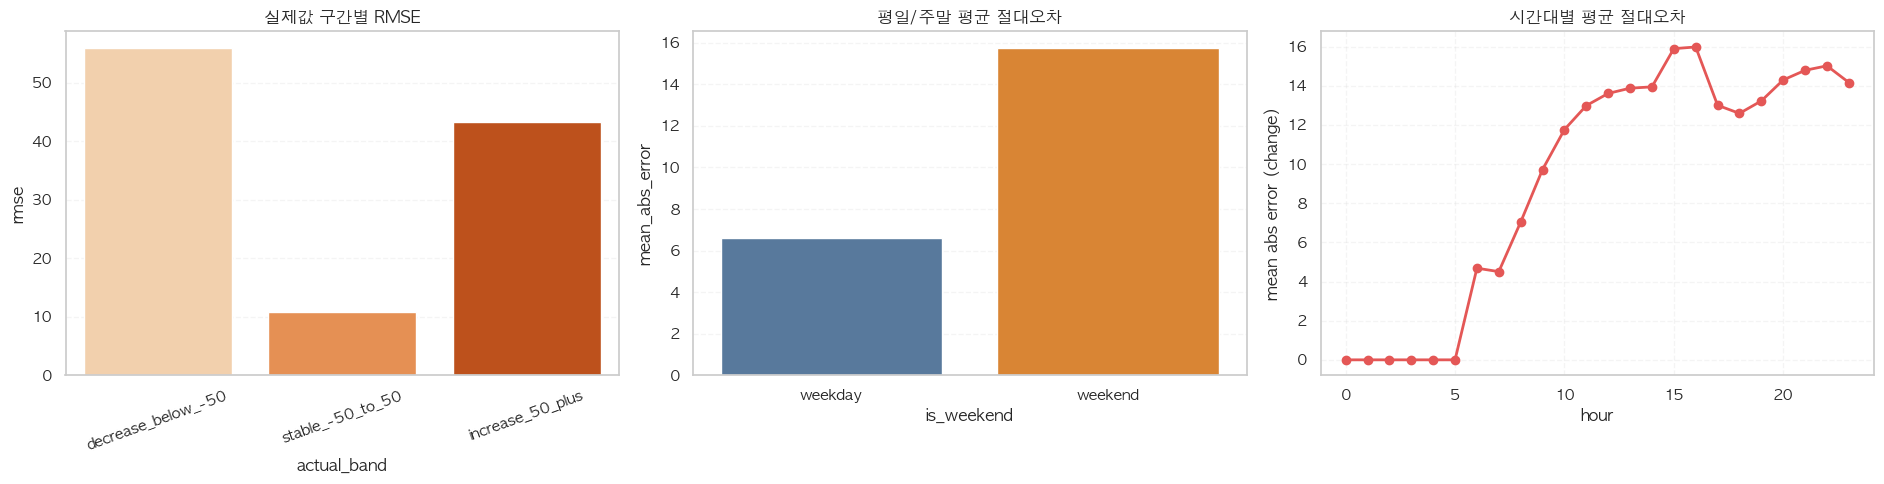

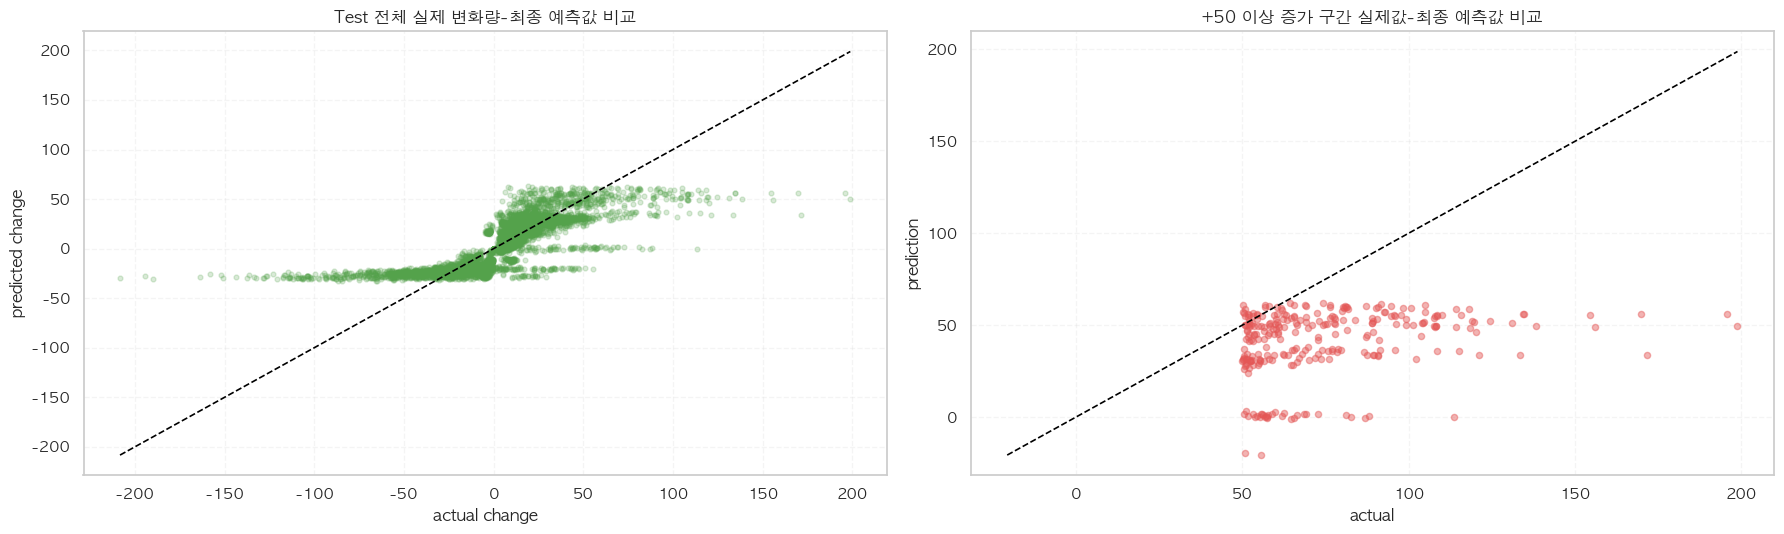

해석: 현재 Ridge 기반 변화량 모델은 전체적으로는 실용적이지만, 큰 폭의 증가 구간에서는 과소예측 가능성을 함께 점검해야 합니다.


In [27]:
high_value_threshold = 50
ridge_limit_view = processed_splits['test'][['datetime', TARGET, 'weather_only_final_prediction']].copy()
ridge_limit_view['abs_error'] = np.abs(ridge_limit_view[TARGET] - ridge_limit_view['weather_only_final_prediction'])
ridge_limit_view['squared_error'] = (ridge_limit_view[TARGET] - ridge_limit_view['weather_only_final_prediction']) ** 2
ridge_limit_view['month'] = ridge_limit_view['datetime'].dt.month
ridge_limit_view['hour'] = ridge_limit_view['datetime'].dt.hour
ridge_limit_view['is_weekend'] = (ridge_limit_view['datetime'].dt.weekday >= 5).astype(int)

high_value_band_df = pd.DataFrame([
    {
        'actual_band': 'decrease_below_-50',
        **calc_metrics(
            ridge_limit_view.loc[ridge_limit_view[TARGET] < -50, TARGET],
            ridge_limit_view.loc[ridge_limit_view[TARGET] < -50, 'weather_only_final_prediction'],
        ),
        'row_count': int((ridge_limit_view[TARGET] < -50).sum()),
    },
    {
        'actual_band': 'stable_-50_to_50',
        **calc_metrics(
            ridge_limit_view.loc[ridge_limit_view[TARGET].between(-50, 50, inclusive='both'), TARGET],
            ridge_limit_view.loc[ridge_limit_view[TARGET].between(-50, 50, inclusive='both'), 'weather_only_final_prediction'],
        ),
        'row_count': int(ridge_limit_view[TARGET].between(-50, 50, inclusive='both').sum()),
    },
    {
        'actual_band': 'increase_50_plus',
        **calc_metrics(
            ridge_limit_view.loc[ridge_limit_view[TARGET] > 50, TARGET],
            ridge_limit_view.loc[ridge_limit_view[TARGET] > 50, 'weather_only_final_prediction'],
        ),
        'row_count': int((ridge_limit_view[TARGET] > 50).sum()),
    },
])

ridge_limit_hourly_df = (
    ridge_limit_view.groupby('hour', as_index=False)
    .agg(mean_abs_error=('abs_error', 'mean'), rmse=('squared_error', lambda x: np.sqrt(x.mean())))
    .sort_values('mean_abs_error', ascending=False)
)
ridge_limit_monthly_df = (
    ridge_limit_view.groupby('month', as_index=False)
    .agg(mean_abs_error=('abs_error', 'mean'), rmse=('squared_error', lambda x: np.sqrt(x.mean())))
    .sort_values('mean_abs_error', ascending=False)
)
ridge_limit_weekend_df = (
    ridge_limit_view.groupby('is_weekend', as_index=False)
    .agg(mean_abs_error=('abs_error', 'mean'), rmse=('squared_error', lambda x: np.sqrt(x.mean())), row_count=(TARGET, 'size'))
)
ridge_limit_peak_cases_df = ridge_limit_view.loc[
    ridge_limit_view[TARGET] > high_value_threshold,
    ['datetime', TARGET, 'weather_only_final_prediction', 'abs_error']
].sort_values(TARGET, ascending=False).head(20)

display(high_value_band_df)
display(ridge_limit_weekend_df)
display(ridge_limit_hourly_df.head(10))
display(ridge_limit_monthly_df.head(12))
display(ridge_limit_peak_cases_df)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.barplot(data=high_value_band_df, x='actual_band', y='rmse', ax=axes[0], palette='Oranges')
axes[0].set_title('실제값 구간별 RMSE')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.2, linestyle='--')

sns.barplot(data=ridge_limit_weekend_df, x='is_weekend', y='mean_abs_error', ax=axes[1], palette=['#4C78A8', '#F58518'])
axes[1].set_title('평일/주말 평균 절대오차')
axes[1].set_xticklabels(['weekday', 'weekend'])
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

top_hour_plot = ridge_limit_hourly_df.sort_values('hour')
axes[2].plot(top_hour_plot['hour'], top_hour_plot['mean_abs_error'], marker='o', linewidth=2.0, color='#E45756')
axes[2].set_title('시간대별 평균 절대오차')
axes[2].set_xlabel('hour')
axes[2].set_ylabel('mean abs error (change)')
axes[2].grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
axes[0].scatter(ridge_limit_view[TARGET], ridge_limit_view['weather_only_final_prediction'], alpha=0.22, s=12, color='#54A24B')
diag_min = min(ridge_limit_view[TARGET].min(), ridge_limit_view['weather_only_final_prediction'].min())
diag_max = max(ridge_limit_view[TARGET].max(), ridge_limit_view['weather_only_final_prediction'].max())
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], linestyle='--', color='black', linewidth=1.2)
axes[0].set_title('Test 전체 실제 변화량-최종 예측값 비교')
axes[0].set_xlabel('actual change')
axes[0].set_ylabel('predicted change')
axes[0].grid(alpha=0.2, linestyle='--')

peak_scatter = ridge_limit_view[ridge_limit_view[TARGET] > high_value_threshold].copy()
axes[1].scatter(peak_scatter[TARGET], peak_scatter['weather_only_final_prediction'], alpha=0.45, s=20, color='#E45756')
peak_min = min(peak_scatter[TARGET].min(), peak_scatter['weather_only_final_prediction'].min())
peak_max = max(peak_scatter[TARGET].max(), peak_scatter['weather_only_final_prediction'].max())
axes[1].plot([peak_min, peak_max], [peak_min, peak_max], linestyle='--', color='black', linewidth=1.2)
axes[1].set_title('+50 이상 증가 구간 실제값-최종 예측값 비교')
axes[1].set_xlabel('actual')
axes[1].set_ylabel('prediction')
axes[1].grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print('해석: 현재 Ridge 기반 변화량 모델은 전체적으로는 실용적이지만, 큰 폭의 증가 구간에서는 과소예측 가능성을 함께 점검해야 합니다.')


## 13. 전체 결과 정리

- 현재 시간별 CSV는 하루 이용량을 단순히 24로 나눈 데이터가 아님
- `0~5시` 행은 존재하지만 `estimated_entries`, `estimated_active_cars` 값은 모두 `0`
- 즉 운영시간 밖 시간대는 남겨두되, 수요는 `0`으로 둔 구조임
- 먼저 입력 변수 분포를 점검했고, 현재 Ridge 파이프라인에는 `StandardScaler`가 있으므로 대부분은 추가 변환 없이도 충분하다고 판단했음
- `bike_rentals`, `bike_returns`, `bike_rental_minutes_sum`, `bike_rental_distance_m_sum`, `direct_radiation`, `estimated_active_cars`는 값이 한쪽으로 많이 몰려 있어 필요하면 `log1p`를 검토할 수 있는 후보로 남겼지만, 이번 버전에서는 적용하지 않았음
- 타깃 값 기준으로는 boxplot 후보가 모두 특이값으로 남아 제거된 행이 없었음
- 입력 변수 점검에서는 `0/1 변수`와 드물게 발생하는 값들은 설명만 남기고 유지했고, 실제로 제거가 필요했던 것은 `bike_rental_minutes_sum`, `bike_rental_distance_m_sum` 두 변수에서 나온 8개 행뿐이었음
- 현재 구조는 `기본 회귀식 + month_weight + hour_weight + Ridge` 조합으로 구성됨
- 즉 먼저 시간대의 큰 흐름을 회귀식과 가중치로 설명하고, 마지막에 Ridge가 외부 변수와 함께 남은 오차를 줄이는 구조임
- 정식 비교 모델 둘만 보면 `weighted_extended`가 더 좋았고, 참고 비교까지 포함하면 `weather_only_extended`가 test 기준으로 가장 높게 나왔음
- 이번 프로젝트에서는 미래 시점에 실제로 확보 가능한 입력을 고려했을 때, `weighted_core`를 기본 뼈대로 두고 날씨만 추가한 `weather_only_extended`를 운영형 모델로 보는 것이 가장 자연스러움
- 그리고 운영 단순화를 위해 단순 예보형 날씨 변수만 남기고 다시 줄인 결과, 최종 채택 모델은 총 13개 feature로 구성됐음
- 최종 feature는 `pattern_prior`, `month_weight`, `hour_weight`, `day_type_offday`, `hour_sin`, `hour_cos`, `month_sin`, `month_cos`, `is_holiday`, `temperature_2m`, `relative_humidity_2m`, `weather_code`, `wind_gusts_10m` 임
- 교통, 자전거, 행사 관련 값은 미래 예측 입력이라기보다, 과거 수요 변화를 설명하는 자료로 해석하는 편이 더 적절함
- 반면 날씨는 가까운 미래 예보를 연결할 수 있으므로, 성능 개선에 도움이 되면서도 운영에 적용 가능한 외부 정보로 볼 수 있음
- 실제값이 매우 큰 `500 이상` 구간에서는 현재 최종 운영형 모델도 과소예측 경향이 있었음
- 따라서 현재 모델은 일반 구간 예측에는 유용하지만, 매우 혼잡한 피크 시간대 해석에는 보수적으로 볼 필요가 있음
- 데이터 분포를 먼저 확인한 결과, 작은 값이 대부분이고 `500 이상` 고값은 드물게 나타나는 긴 꼬리 구조였음
- 그럼에도 이번 프로젝트에서는 해석이 쉽고 운영 입력 구성이 단순한 Ridge 선형 회귀 모델을 최종 운영형으로 유지하기로 했음
- 따라서 최종 운영안은 13개 feature를 사용하는 `weather_only_extended_final` Ridge 모델이며, 고혼잡 구간 한계는 설명으로 함께 관리하는 방향으로 정리할 수 있음


## 14. 여유 주차공간 수로 바꾸는 방법

이번 모델이 직접 예측하는 값은 `estimated_active_cars`입니다. 이를 **해당 시점에 주차 중인 차량 수 추정값**으로 해석하면, 여유 주차공간 수는 아래처럼 계산할 수 있습니다.

- `predicted_occupied_cars = predicted_estimated_active_cars`
- `total_capacity = 난지 주차장의 총 주차면 수`
- `available_spaces = max(total_capacity - predicted_occupied_cars, 0)`

즉 총 주차면 수에서 예측된 주차 차량 수를 빼면, 남아 있는 자리 수를 계산할 수 있습니다.

실제 활용 시에는 먼저 13개 feature를 사용하는 Ridge 기본모델로 전체 흐름을 예측하고, 그 다음 `500 이상` 고혼잡 가능성이 높은 시점만 라우터 모델이 골라 비선형 피크 모델로 다시 예측하는 방식이 가장 자연스럽습니다. 즉 현재 시점에 알 수 있는 패턴 정보와 가까운 미래 날씨 예보를 함께 사용해 기본 점유량을 예측한 뒤, 고혼잡 후보 시점만 한 번 더 보정해서 `1시간 뒤`, `3시간 뒤`, `하루 뒤`의 점유량을 만들고, 이를 여유 주차공간 수로 바꾸는 방향이 이번 프로젝트의 운영 시나리오에 가장 잘 맞습니다.


In [28]:
change_forecast_view = test_df[[
    'datetime', TARGET,
    'weighted_core_prediction', 'weighted_extended_prediction',
]].copy()
change_forecast_view = change_forecast_view.rename(columns={TARGET: 'actual_estimated_active_cars_change'})

if 'weather_only_final_prediction' in processed_splits['test'].columns:
    change_forecast_view['weather_only_final_prediction'] = processed_splits['test']['weather_only_final_prediction'].to_numpy()

print('변화량 타깃에서는 TOTAL_CAPACITY만으로 여유면수를 직접 계산하지 않습니다.')
print('운영형 변화량 활용식 예시: next_estimated_active_cars = current_actual_cars + weather_only_final_prediction')
display(change_forecast_view.head())


변화량 타깃에서는 TOTAL_CAPACITY만으로 여유면수를 직접 계산하지 않습니다.
운영형 변화량 활용식 예시: next_estimated_active_cars = current_actual_cars + weather_only_final_prediction


,datetime,actual_estimated_active_cars_change,weighted_core_prediction,weighted_extended_prediction,weather_only_final_prediction
0,2025-01-01 00:00:00,0.0,0.0,0.0,0.0
1,2025-01-01 01:00:00,0.0,0.0,0.0,0.0
2,2025-01-01 02:00:00,0.0,0.0,0.0,0.0
3,2025-01-01 03:00:00,0.0,0.0,0.0,0.0
4,2025-01-01 04:00:00,0.0,0.0,0.0,0.0


In [29]:
metrics_df.to_csv(OUTPUT_DIR / 'nanji_model_metrics.csv', index=False, encoding='utf-8-sig')
tuning_df.to_csv(OUTPUT_DIR / 'nanji_model_tuning.csv', index=False, encoding='utf-8-sig')
importance_df.to_csv(OUTPUT_DIR / 'nanji_feature_importance.csv', index=False, encoding='utf-8-sig')
weight_df.to_csv(OUTPUT_DIR / 'nanji_weight_table.csv', index=False, encoding='utf-8-sig')
outlier_rule_df.to_csv(OUTPUT_DIR / 'nanji_outlier_rule_summary.csv', index=False, encoding='utf-8-sig')
removed_outliers_df.to_csv(OUTPUT_DIR / 'nanji_removed_outliers.csv', index=False, encoding='utf-8-sig')
special_cases_df.to_csv(OUTPUT_DIR / 'nanji_special_cases.csv', index=False, encoding='utf-8-sig')
feature_normality_df.to_csv(OUTPUT_DIR / 'nanji_feature_normality_audit.csv', index=False, encoding='utf-8-sig')
feature_outlier_audit_df.to_csv(OUTPUT_DIR / 'nanji_feature_outlier_audit.csv', index=False, encoding='utf-8-sig')
feature_outlier_removed_rows_df.to_csv(OUTPUT_DIR / 'nanji_feature_removed_rows.csv', index=False, encoding='utf-8-sig')

if 'final_operational_comparison' in globals():
    final_operational_comparison.to_csv(OUTPUT_DIR / 'nanji_weather_only_comparison.csv', index=False, encoding='utf-8-sig')
if 'feature_drop_df' in globals():
    feature_drop_df.to_csv(OUTPUT_DIR / 'nanji_weather_only_feature_drop_scan.csv', index=False, encoding='utf-8-sig')
if 'final_feature_summary_df' in globals():
    final_feature_summary_df.to_csv(OUTPUT_DIR / 'nanji_final_operational_feature_list.csv', index=False, encoding='utf-8-sig')


test_export_columns = [
    'datetime', TARGET, 'weighted_core_prediction', 'weighted_extended_prediction',
    'base_value', 'month_weight', 'hour_weight',
    'pattern_prior', 'corrected_pattern_prior'
]
if 'weather_only_extended_prediction' in processed_splits['test'].columns:
    test_export_columns.append('weather_only_extended_prediction')
if 'weather_only_final_prediction' in processed_splits['test'].columns:
    test_export_columns.append('weather_only_final_prediction')

processed_splits['test'][test_export_columns].to_csv(OUTPUT_DIR / 'nanji_test_predictions.csv', index=False, encoding='utf-8-sig')

print('saved to:', OUTPUT_DIR)
print('report path:', REPORT_PATH)


saved to: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_outputs_change
report path: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_weighted_ridge_change_modeling_report.md
